# Import Libraries

In [1]:
#Khai báo các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgboostr
from xgboost import XGBRFRegressor
from sklearn.preprocessing import  LabelEncoder
from sklearn.ensemble                 import RandomForestRegressor
from sklearn.model_selection          import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ks_2samp
from sklearn.linear_model import LinearRegression

# Load Train Data/Observe Basic Info
#Quan sát dữ liệu thô, thực hiện Data cleaning vàđưa ra quyết định loại bỏ các dữ liệu gây loãng -> Tiến tới phân tách biến trước khi bước vào giai đoạn EDA

In [2]:
#Upload file dữ liệu thô
df = pd.read_csv("sellout_w.csv")

In [3]:
#Kiểm tra độ lớn của bộ dữ liệu và định dạng của từng cột
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29795 entries, 0 to 29794
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   bill_date                29795 non-null  object 
 1   customer_id              29795 non-null  int64  
 2   customer_name            29795 non-null  object 
 3   address                  29795 non-null  object 
 4   product_code             29795 non-null  object 
 5   product_name             29795 non-null  object 
 6   unit_name                29795 non-null  object 
 7   unit                     29795 non-null  int64  
 8   unit_price               29795 non-null  int64  
 9   tax_rate                 29795 non-null  int64  
 10  cost                     29795 non-null  int64  
 11  note_promotion           5549 non-null   object 
 12  discount_promotion_code  6474 non-null   object 
 13  entity                   29795 non-null  object 
 14  quantity_tons         

In [4]:
df.head()

,bill_date,customer_id,customer_name,address,product_code,product_name,unit_name,unit,unit_price,tax_rate,cost,note_promotion,discount_promotion_code,entity,quantity_tons,product
0,1/5/2023,5105004256,WCM,Site 1,7.A319908993301,VIETNAMESE PANCAKE MIX 400G X 6 BAG,CAR,5,94500,10,519750,NaN,NaN,Gvap,0.0120,VIETNAMESE PANCAKE MIX 400G X 6 BAG
1,1/5/2023,5105004256,WCM,Site 1,7.A33020899890118,PREMIUM MACARONI - SPIRAL 300G X 12 PACK,CAR,3,211200,10,696960,NaN,NaN,Gvap,0.0108,PREMIUM MACARONI - SPIRAL 300G X 12 PACK
2,1/5/2023,5105004256,WCM,Site 1,7.A320580997701,SPAGHETTI N.5 500G X 18 BOX,CAR,1,762300,10,838530,NaN,NaN,Gvap,0.0090,SPAGHETTI N.5 500G X 18 BOX
3,1/12/2023,5105004256,WCM,Site 1,7.A320108997901,PREMIUM EGG NOODLE 500G X 12 BAG,CAR,5,312000,10,1716000,NaN,NaN,Gvap,0.0300,PREMIUM EGG NOODLE 500G X 12 BAG
4,1/12/2023,5105004256,WCM,Site 1,7.A33020899890118,PREMIUM MACARONI - SPIRAL 300G X 12 PACK,CAR,2,211200,10,464640,NaN,NaN,Gvap,0.0072,PREMIUM MACARONI - SPIRAL 300G X 12 PACK


In [5]:
#Convert bill_date sang dạng datetime do trước đó đang là Object
df['bill_date'] = pd.to_datetime(df['bill_date'])

In [6]:
c = df.nunique()
c

bill_date                   360
customer_id                   6
customer_name                 1
address                      51
product_code                134
product_name                136
unit_name                     3
unit                        648
unit_price                  268
tax_rate                      2
cost                       6454
note_promotion              173
discount_promotion_code     265
entity                        7
quantity_tons              2018
product                     136
dtype: int64

In [7]:
#Loại bỏ các cột không cần thiết do mục tiêu bài toán cần giải là forecast doanh số bán của từng sản phẩm trong 136 products unique được xác định ở trên
df = df.drop(columns = (['customer_id','customer_name','address','unit_name','quantity_tons','tax_rate','product_name','product_code']), axis = 1)

In [8]:
#Xác định mục tiêu cần dự báo, phân loại 2 nhóm biến số và biến phân loại
tar_col = 'unit'
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
num_cols, cat_cols,tar_col

(['unit', 'unit_price', 'cost'],
 ['bill_date',
  'note_promotion',
  'discount_promotion_code',
  'entity',
  'product'],
 'unit')

# EDA

## Target
#Phân tích mục tiêu

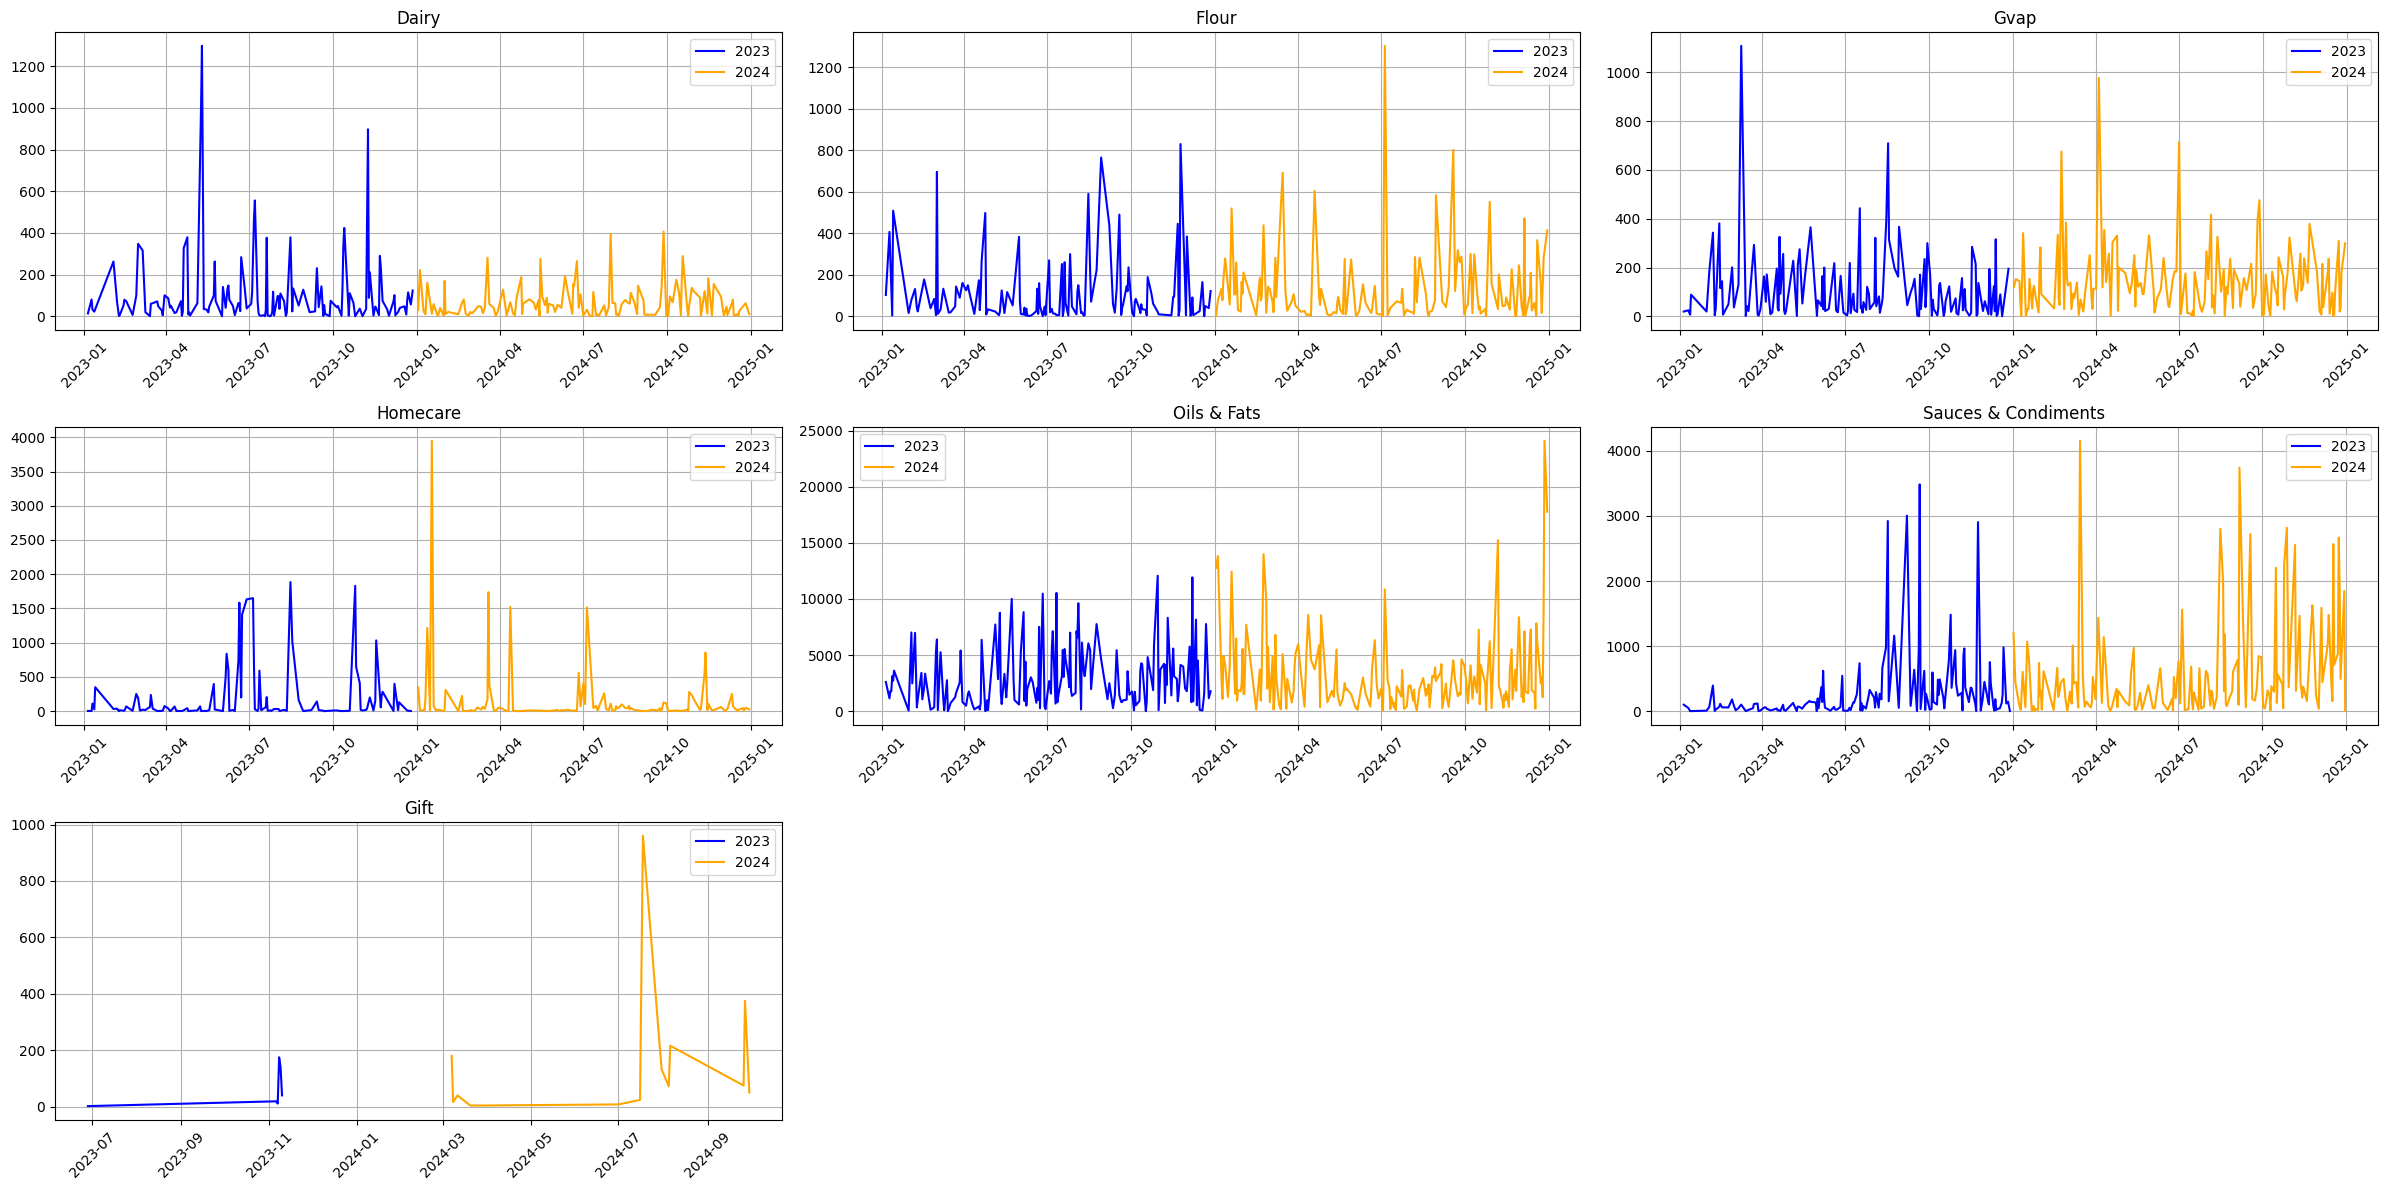

In [9]:
#Vẽ biểu đồ doanh số theo thời gian cho từng ngành hàng (Entity) xem có seasonality hay pattern gì không, group theo enity để so sánh các ngành hàng 
# -> Ngành hàng Oils & Fats + Sauces & Condiments có doanh số lớn nhất nhưng cũng biến động cực kỳ mạnh.
df_grouped = df.groupby(['bill_date', 'entity'])['unit'].sum().reset_index()

df_grouped['bill_date'] = pd.to_datetime(df_grouped['bill_date'])

entities = df_grouped['entity'].unique()

fig, axes = plt.subplots(3, 3, figsize=(24, 12))
axes = axes.flatten()

for i, entity in enumerate(entities):
    subset = df_grouped[df_grouped['entity'] == entity]
    
    subset_2023 = subset[subset['bill_date'].dt.year == 2023]
    subset_2024 = subset[subset['bill_date'].dt.year == 2024]
    
    axes[i].plot(subset_2023['bill_date'], subset_2023['unit'], label='2023', color='blue')
    axes[i].plot(subset_2024['bill_date'], subset_2024['unit'], label='2024', color='orange')
    
    axes[i].set_title(entity)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True)
    axes[i].legend()  
    
for j in range(len(entities), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


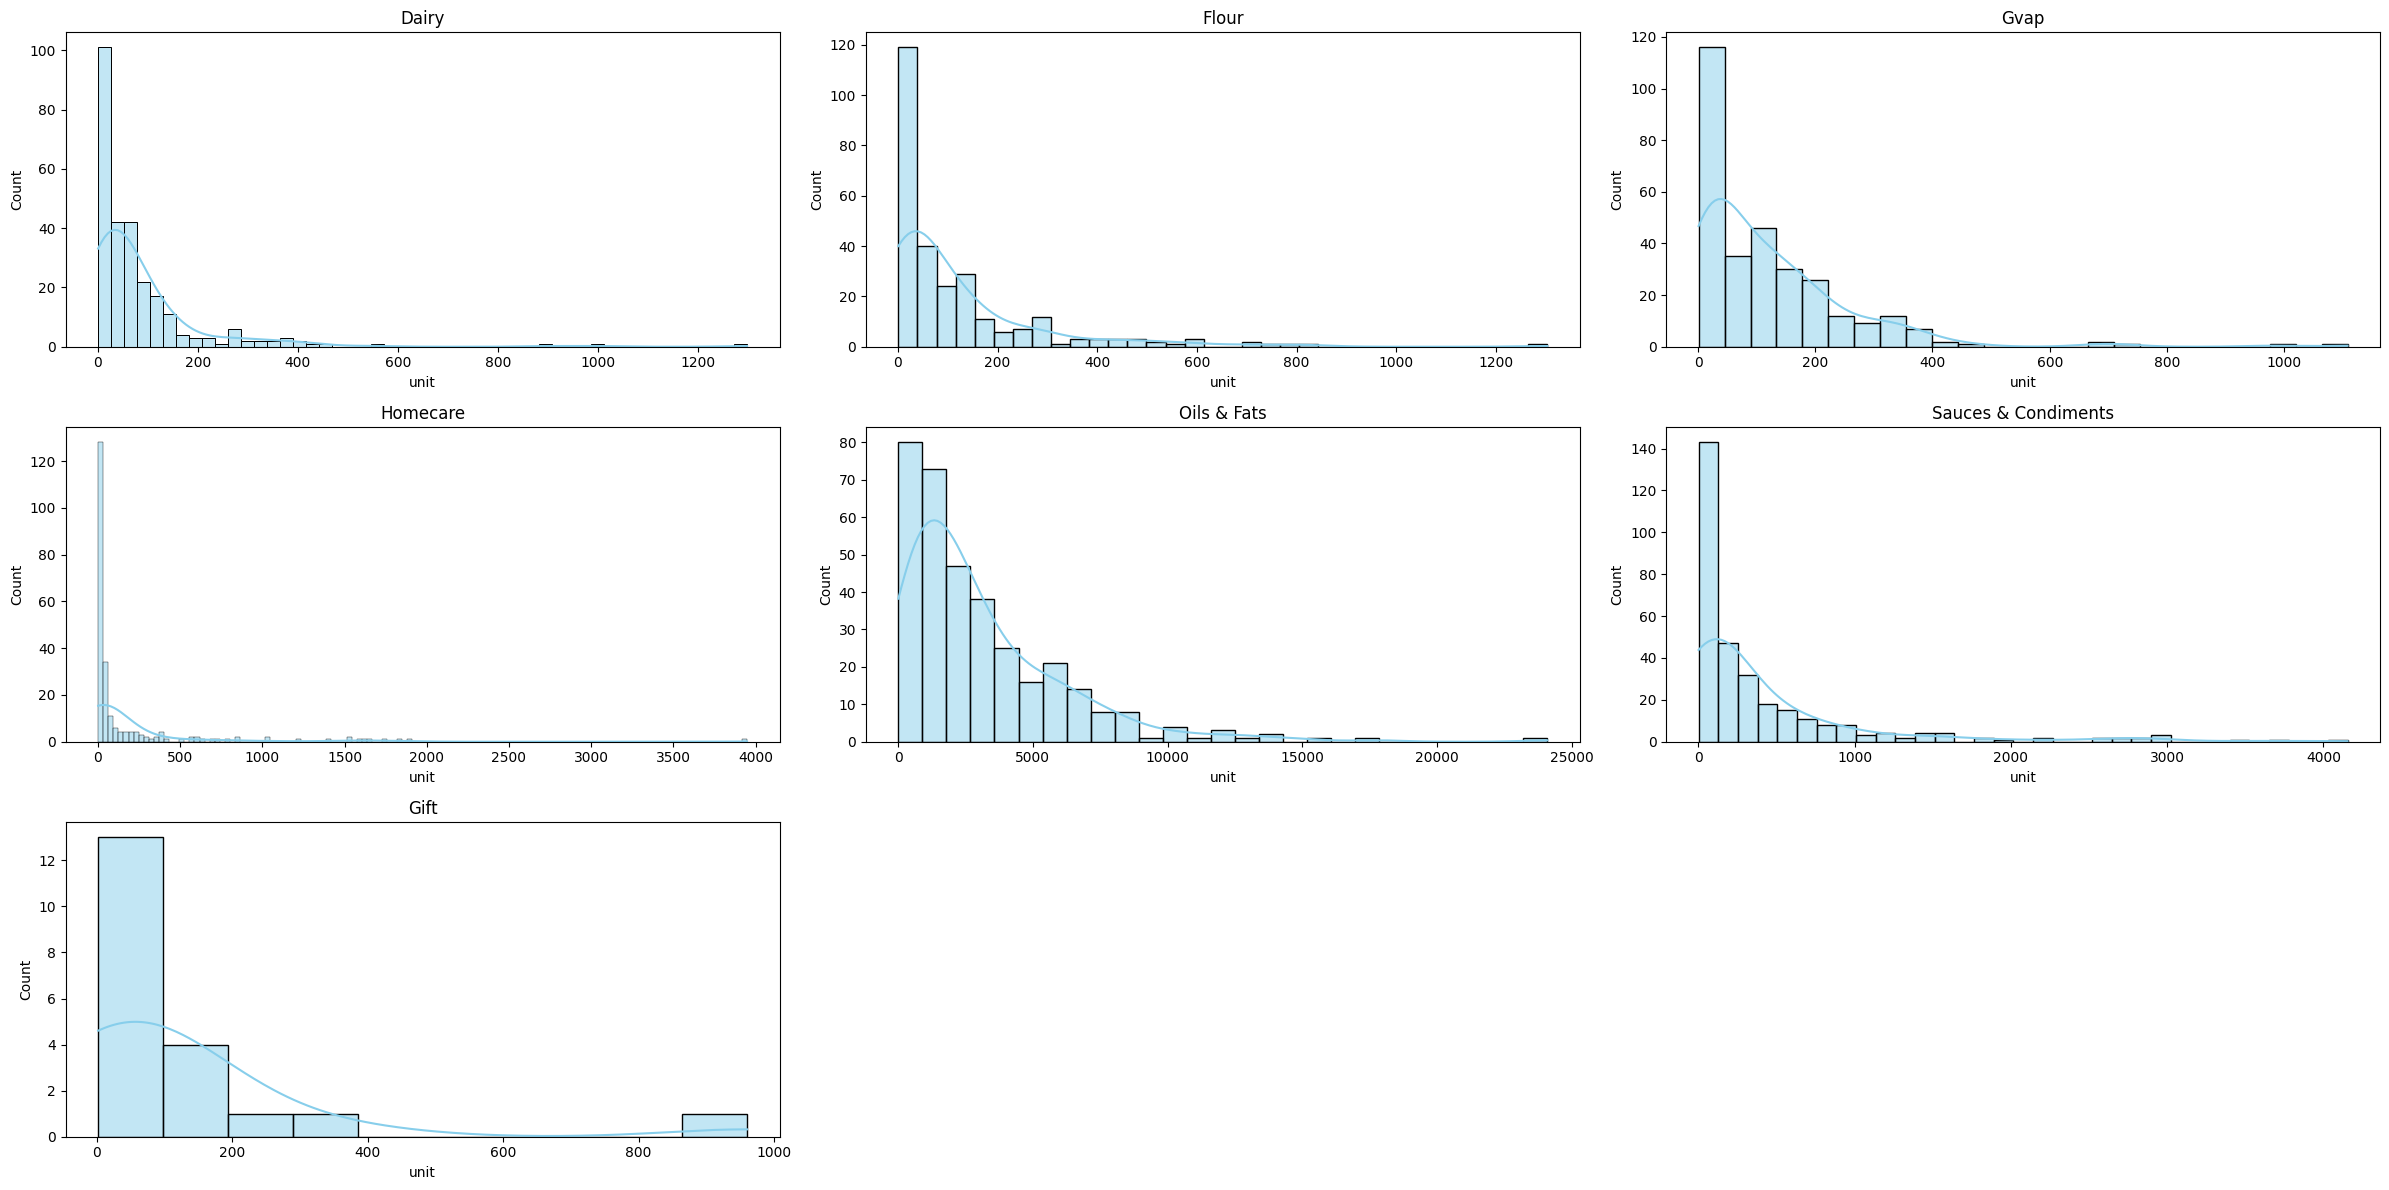

In [10]:
#Histogram phân bổ Unit theo từng Entity -> Cần xem distribution của biến target để biết data có skew không, có outlier không
# Phân bố bị lệch phải nặng -> đa phần đơn hàng số lượng nhỏ, ít đơn lớn. Xuất hiện outlier rõ -> Định hướng dùng XGBoost, Random Forest vì chịu outlier tốt hơn Linear Regression
fig, axes = plt.subplots(3, 3, figsize=(24, 12))
axes = axes.flatten()

for i, entity in enumerate(entities):
    subset = df_grouped[df_grouped['entity'] == entity]['unit']
    
    # Plot histogram
    sns.histplot(subset, ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(entity)
    axes[i].set_xlabel('unit')
    axes[i].set_ylabel('Count')

for j in range(len(entities), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
#Kiểm tra date range và missing dates -> Data từ khoảng 2 năm. Có một số ngày missing -> cần lưu ý khi tạo lag features
print(f"Date range: {df['bill_date'].min()} to {df['bill_date'].max()}")
print(f"Total unique dates: {df['bill_date'].nunique()}")
all_dates = pd.date_range(df['bill_date'].min(), df['bill_date'].max())

Date range: 2023-01-05 00:00:00 to 2024-12-31 00:00:00
Total unique dates: 360


In [12]:
#Kiểm tra mỗi ngành hàng có bao nhiêu ngày không có giao dịch, hoặc có giao dịch nhưng số bán = 0 
# -> Một số ngành hàng có nhiều ngày missing hơn -> không phải ngày nào cũng có đơn hàng, điều này bình thường trong thực tế
entities = df['entity'].unique()
for ent in entities:
    ent_df = df[df['entity'] == ent]
    daily = ent_df.groupby('bill_date')['unit'].sum().reset_index()
    missing = all_dates.difference(daily['bill_date'])
    zero_days = daily[daily['unit'] == 0]['bill_date']
    print(f"\nEntity: {ent}")
    print(f"Missing days: {len(missing)}")
    print(f"Zero-sales days: {len(zero_days)}")


Entity: Gvap
Missing days: 426
Zero-sales days: 0

Entity: Dairy
Missing days: 458
Zero-sales days: 0

Entity: Sauces & Condiments
Missing days: 411
Zero-sales days: 0

Entity: Oils & Fats
Missing days: 382
Zero-sales days: 0

Entity: Flour
Missing days: 454
Zero-sales days: 0

Entity: Homecare
Missing days: 495
Zero-sales days: 0

Entity: Gift
Missing days: 707
Zero-sales days: 0


In [13]:
#Tính z-score với rolling window 30 ngày để detect outlier (|z| > 3) ở cấp ngành hàng Entity
#Phát hiện được số lượng outlier rows. Các outlier này là những ngày bán có số đột biến (trong case này là quá cao so với trend)
df_grouped['rolling_mean'] = df_grouped.groupby('entity')['unit'].transform(lambda x: x.rolling(30, center=True).mean())
df_grouped['rolling_std']  = df_grouped.groupby('entity')['unit'].transform(lambda x: x.rolling(30, center=True).std())
df_grouped['z_score'] = (df_grouped['unit'] - df_grouped['rolling_mean']) / df_grouped['rolling_std']

outliers = df_grouped[df_grouped['z_score'].abs() > 3]
print(f"Detected {len(outliers)} outlier rows (z-score > 3)")

Detected 40 outlier rows (z-score > 3)


In [14]:
#Tính z-score với rolling window 30 ngày để detect outlier (|z| > 3) ở cấp sản phẩm Product
df_grouped2 = df.groupby(['bill_date', 'product'])['unit'].sum().reset_index()

In [15]:
#Phát hiện sản phẩm nào có đơn hàng bất thường
df_grouped2['rolling_mean'] = df_grouped2.groupby('product')['unit'].transform(lambda x: x.rolling(30, center=True).mean())
df_grouped2['rolling_std']  = df_grouped2.groupby('product')['unit'].transform(lambda x: x.rolling(30, center=True).std())
df_grouped2['z_score'] = (df_grouped2['unit'] - df_grouped2['rolling_mean']) / df_grouped2['rolling_std']

outliers = df_grouped2[df_grouped2['z_score'].abs() > 3]
print(f"Detected {len(outliers)} outlier rows (z-score > 3)")

Detected 246 outlier rows (z-score > 3)


In [16]:
#View các dòng outlier đó là gì
outliers

,bill_date,product,unit,rolling_mean,rolling_std,z_score
658,2023-03-02,CO-S SBO 2L X 6 BTL,6357,1101.600000,1711.644472,3.070381
683,2023-03-06,CO-LIGHT 2L X 6 BTL,3903,646.666667,1004.322531,3.242318
738,2023-03-09,CO-OLIVE OIL 0.25L X 12 BTL,301,55.400000,71.906357,3.415553
974,2023-03-28,CO-LIGHT 1L X 12 BTL,2961,173.300000,547.268335,5.093845
997,2023-03-30,CO-M SBO 1L X 12 BTL,336,42.866667,76.165307,3.848646
...,...,...,...,...,...,...
11069,2024-11-15,CO-OLIVE OIL 0.25L X 12 BTL,540,104.433333,137.745814,3.162105
11086,2024-11-15,HOT CHILI SAUCE 255G X 24 BOT/CAR,119,19.166667,25.127377,3.973090
11174,2024-11-21,CO-S SBO 1L X 12 BTL,3571,637.000000,951.126592,3.084763
11241,2024-11-25,PORK BOUILLON GRANULE 400G X 24 PAC/CAR,1001,184.300000,269.104409,3.034882


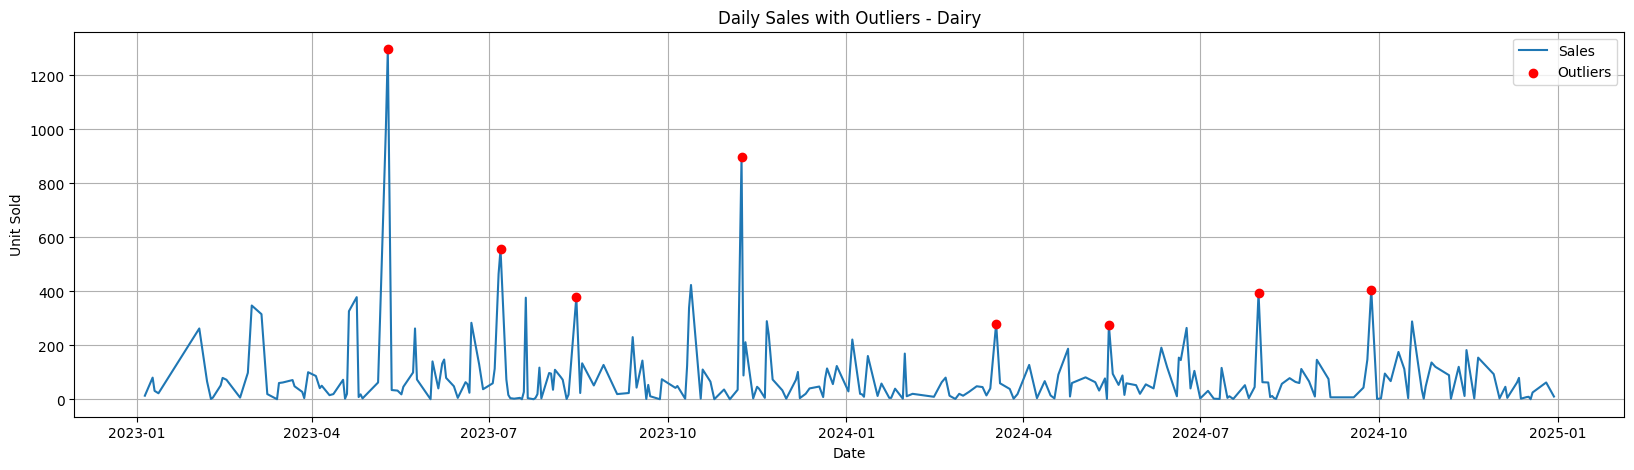

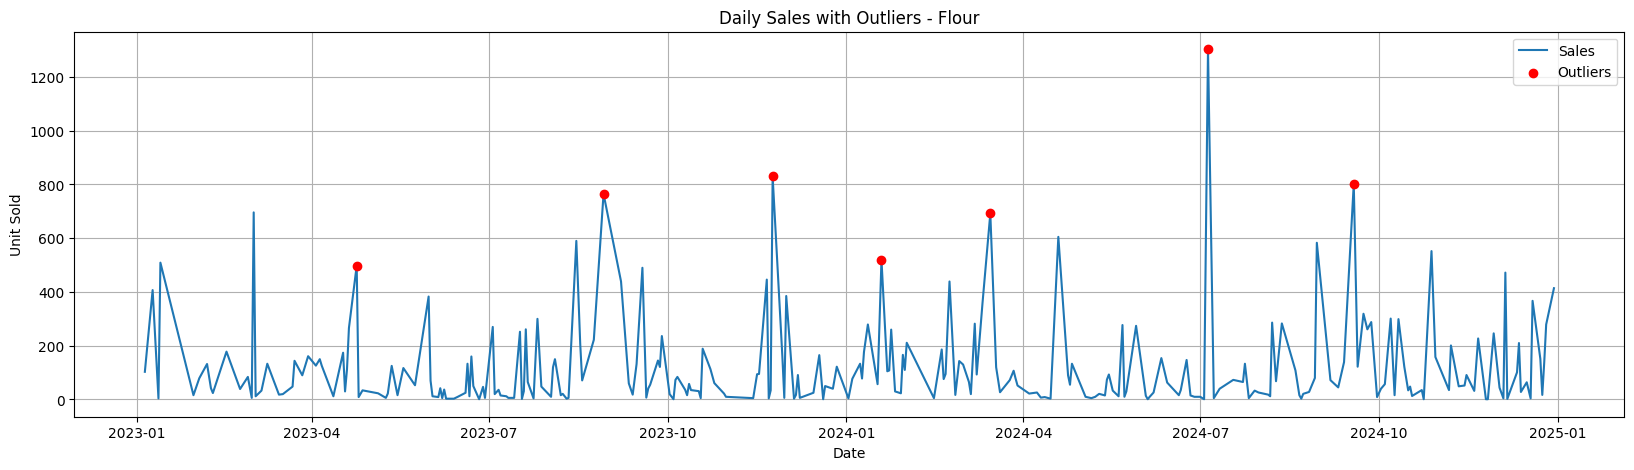

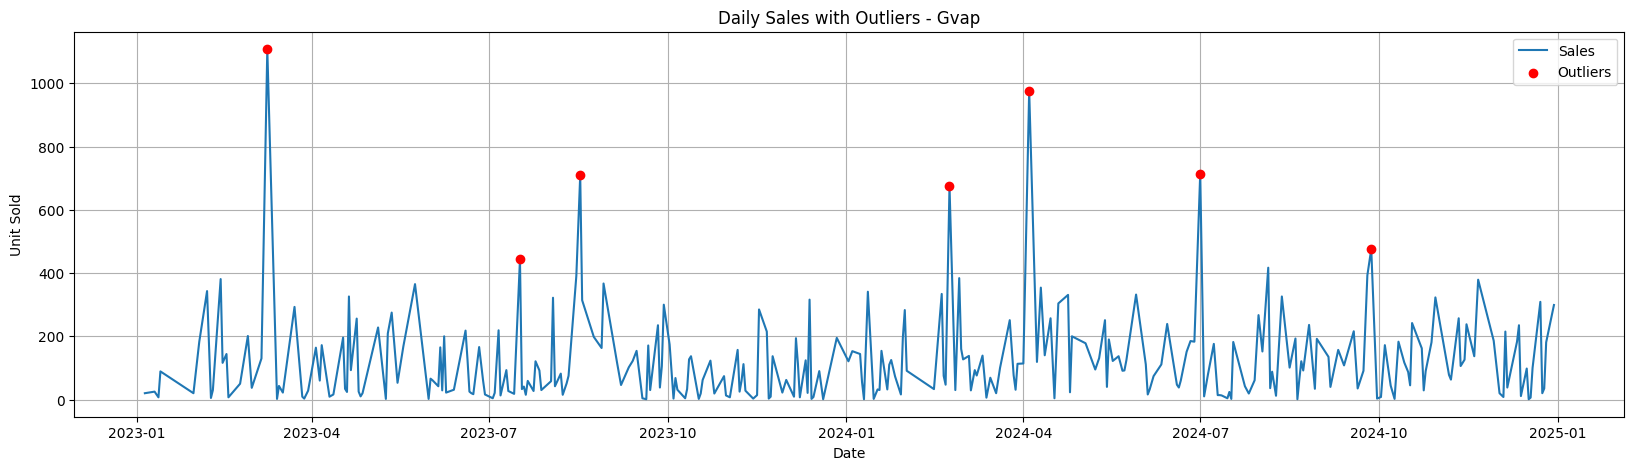

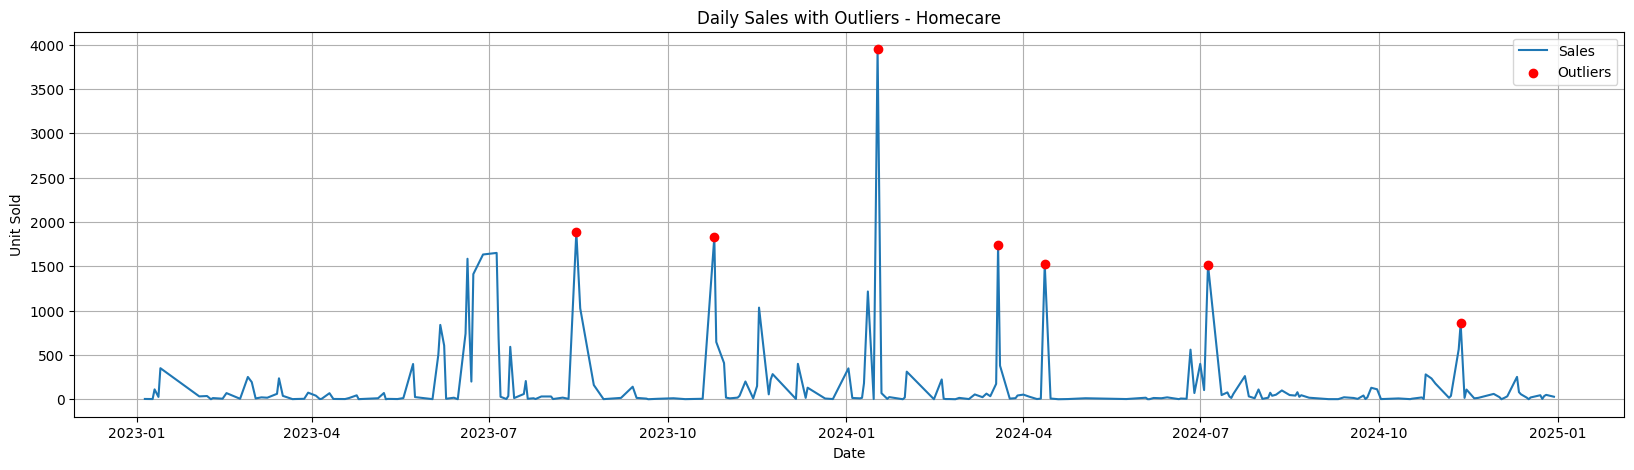

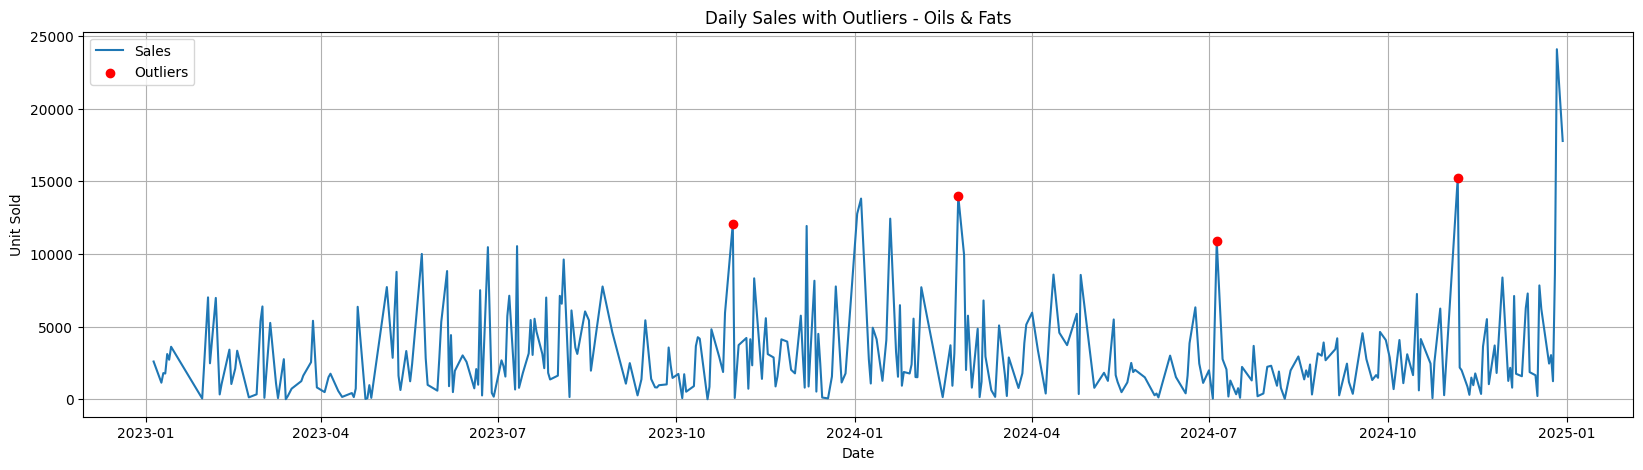

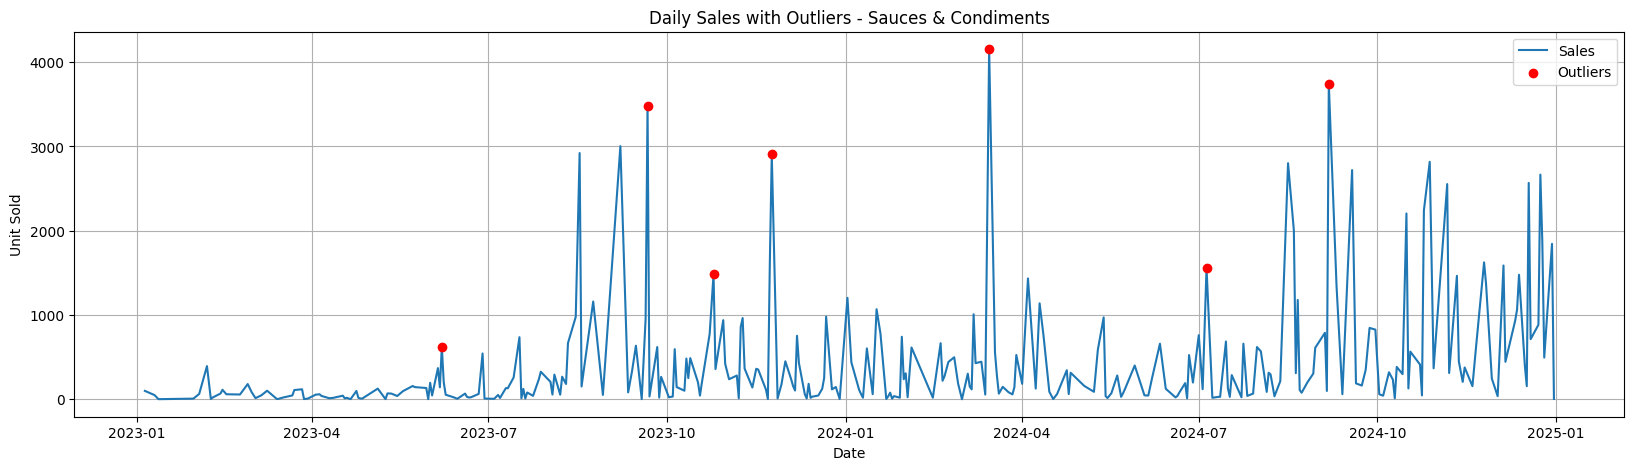

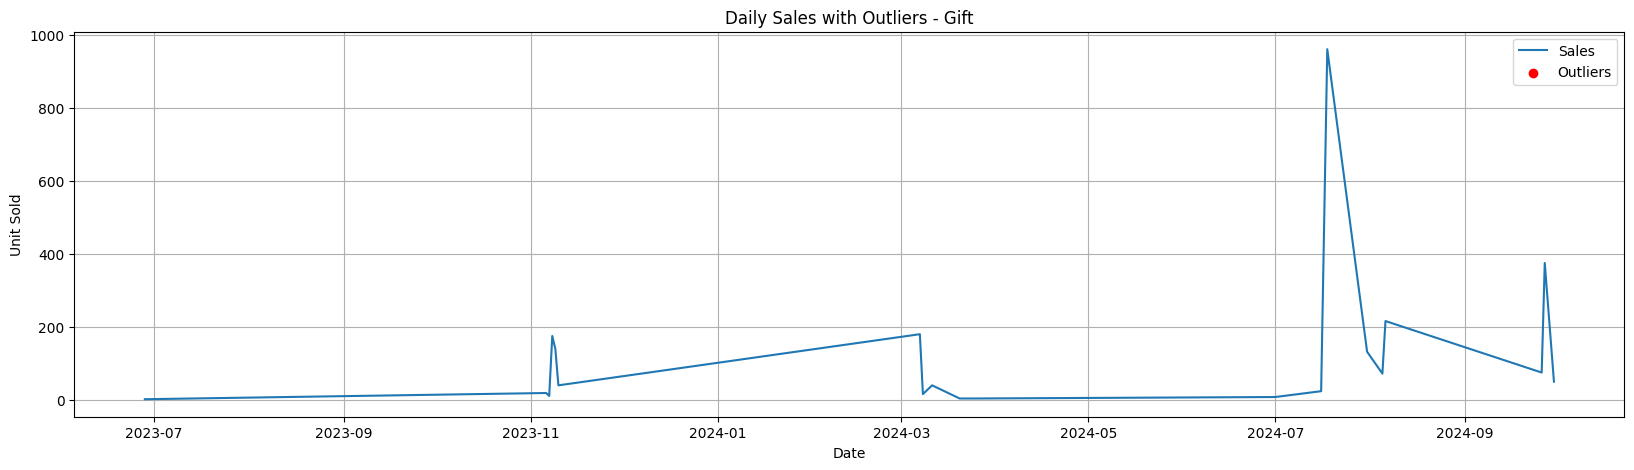

In [17]:
#Visualize outlier được đánh dâu đỏ trên line chart để thấy trực quan chúng nằm ở đâu trên timeline (Reconfirm lại việc detect outlier)
for ent in df_grouped['entity'].unique():
    subset = df_grouped[df_grouped['entity'] == ent]
    outlier_subset = subset[subset['z_score'].abs() > 3]

    plt.figure(figsize=(20, 5))
    plt.plot(subset['bill_date'], subset['unit'], label='Sales')
    plt.scatter(outlier_subset['bill_date'], outlier_subset['unit'], color='red', label='Outliers', zorder=5)
    plt.title(f'Daily Sales with Outliers - {ent}')
    plt.xlabel('Date')
    plt.ylabel('Unit Sold')
    plt.legend()
    plt.grid(True)
    plt.show()

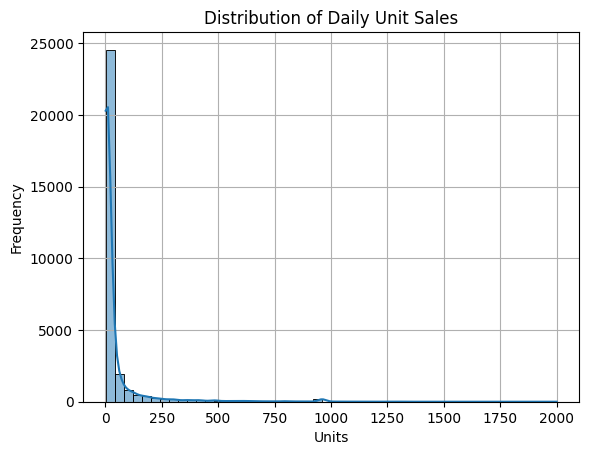

In [18]:
#Xem distribution tổng thể của biến Target -> Confirm phân bố heavily right-skewed. Đa số giao dịch có unit nhỏ, rất ít giao dịch unit lớn.
#Kết luận section EDA Target: Biến target (unit) bị skew phải nặng, nhiều outlier, có pattern theo thời gian. Oils & Fats và Sauces biến động mạnh nhất. Định hướng dùng tree-based model
sns.histplot(df['unit'], bins=50, kde=True)
plt.title('Distribution of Daily Unit Sales')
plt.xlabel('Units')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Num

In [19]:
#Cần xem thống kê mô tả cho các biến số để phát hiện range, spread, potential outlier -> Thấy cost và unit có range rất rộng, confirm có outlier. unit_price ổn định hơn

df[num_cols].describe()

,unit,unit_price,cost
count,29795.000000,2.979500e+04,2.979500e+04
mean,44.825608,3.829135e+05,2.453229e+07
std,130.820790,2.966308e+05,9.140319e+07
min,1.000000,0.000000e+00,0.000000e+00
25%,2.000000,1.417500e+05,2.944510e+05
50%,6.000000,3.403680e+05,1.570800e+06
75%,23.000000,6.756000e+05,7.241918e+06
max,2000.000000,1.408770e+06,1.602480e+09


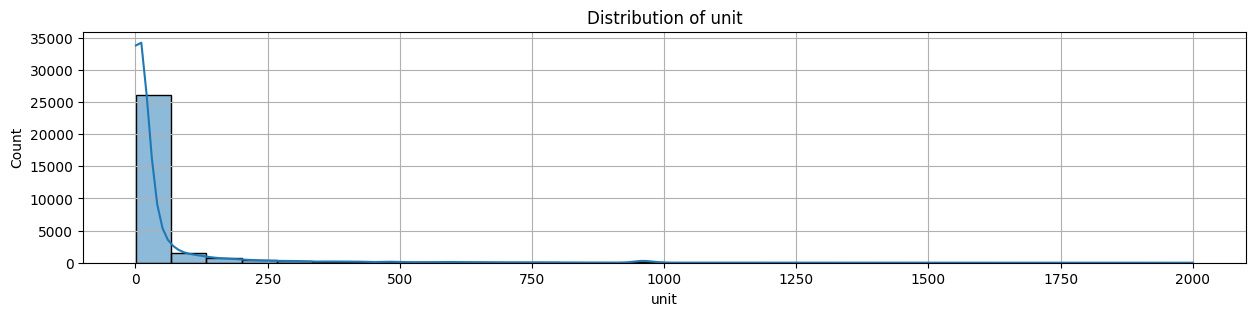

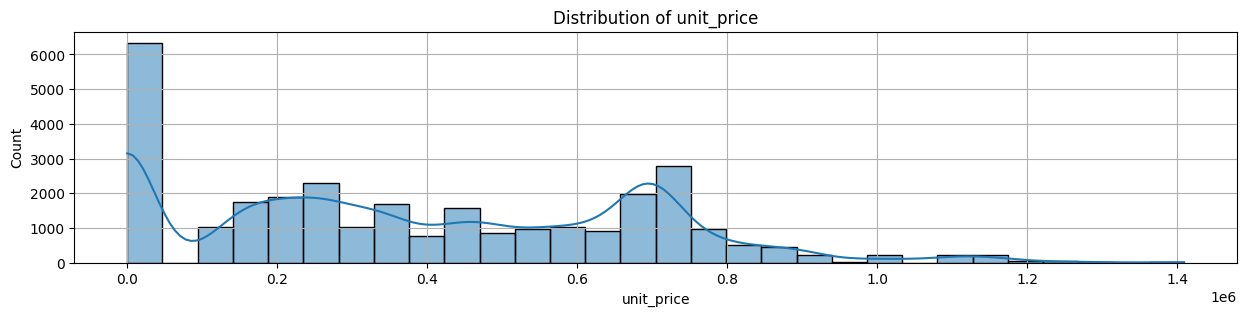

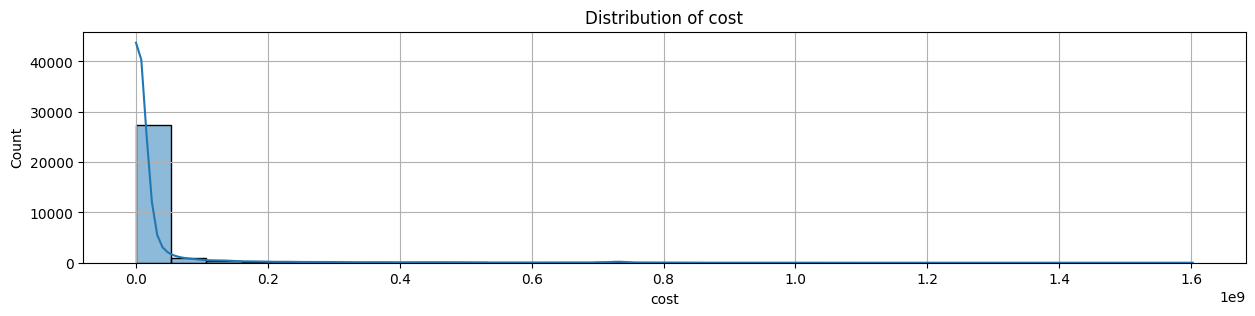

In [20]:
#Xem distribution của từng biến số riêng lẻ -> Data phân bổ không chuẩn
for col in num_cols:
    plt.figure(figsize=(15, 3))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.grid(True)
    plt.show()

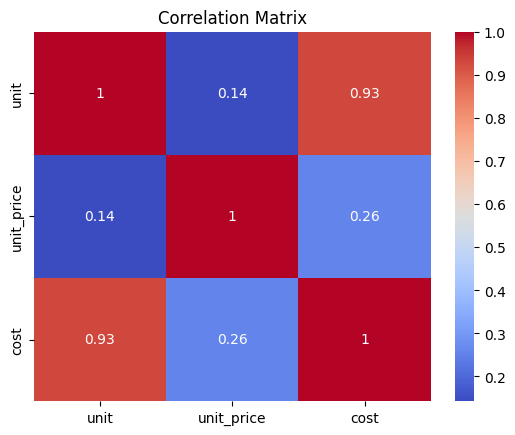

In [21]:
#Vẽ correlation matrix để phát hiện mối quan hệ tuyến tính giữa các biến số với nhau và với target
#unit và cost có correlation rất cao (gần 1) -> hợp lý vì cost = unit * price, unit_price correlation thấp hơn với unit
correlations = df[num_cols].corr()
sns.heatmap(correlations, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

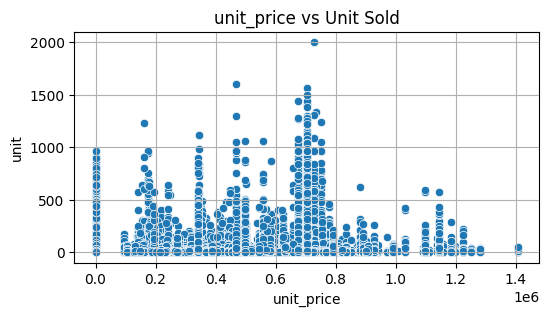

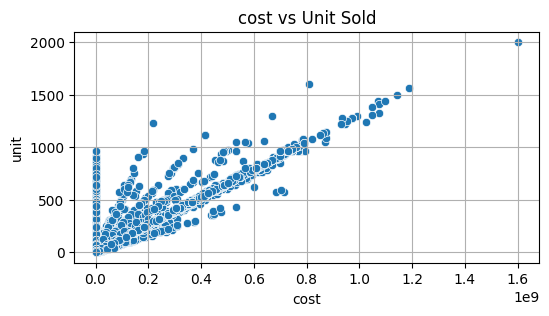

In [22]:
#Vẽ scatter plot để thấy pattern, linear hay non-linear relationship cụ thể giữa từng biến số với target
#cost vs unit gần như linear (do công thức). unit_price vs unit không có pattern rõ ràng -> relationship phức tạp hơn
for col in num_cols:
    if col != 'unit':
        plt.figure(figsize=(6, 3))
        sns.scatterplot(x=df[col], y=df['unit'])
        plt.title(f'{col} vs Unit Sold')
        plt.grid(True)
        plt.show()

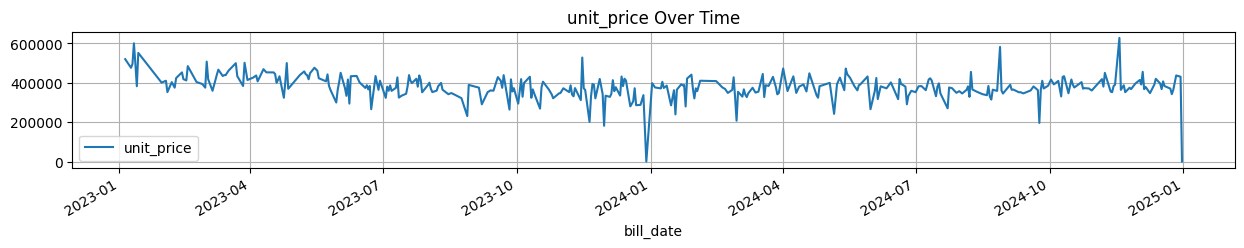

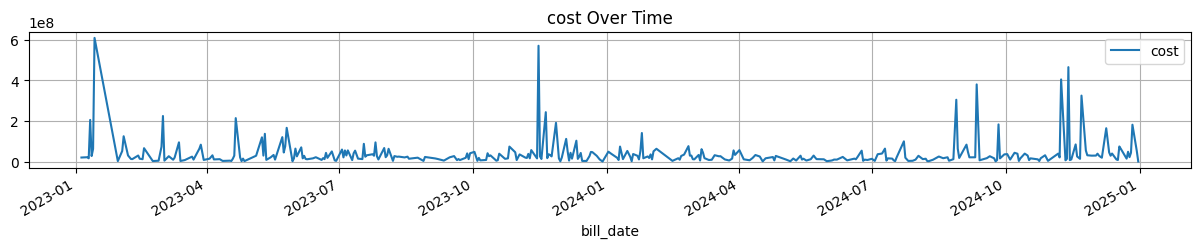

In [23]:
#Plot mean giá trị từng biến theo ngày để thấy trend
#Kết luận section EDA Num: Các biến số đều skewed, cost-unit correlation cao (đúng logic, công thức). unit_price sẽ là feature quan trọng vì ảnh hưởng đến hành vi mua 
for col in num_cols:
    if col != 'unit':
        df_temp = df[['bill_date', col]].groupby('bill_date').mean()
        df_temp.plot(figsize=(15, 2), title=f'{col} Over Time')
        plt.grid(True)
        plt.show()

## Cat

In [24]:
#Cần biết độ đa dạng của từng biến phân loại
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

bill_date: 360 unique values
note_promotion: 173 unique values
discount_promotion_code: 265 unique values
entity: 7 unique values
product: 136 unique values


In [25]:
#Muốn biết giá trị nào xuất hiện nhiều nhất trong mỗi biến phân loại
# -> Thấy được sản phẩm nào bán nhiều nhất, ngành hàng nào chiếm tỷ trọng lớn
for col in cat_cols:
    print(f"\nTop categories in {col}:")
    print(df[col].value_counts().head())


Top categories in bill_date:
bill_date
2024-11-21    301
2024-11-06    279
2024-01-12    267
2024-02-23    249
2023-08-24    247
Name: count, dtype: int64

Top categories in note_promotion:
note_promotion
MIX/240312/050         140
MIX/231220/276         133
MIX/230711/160         121
CQ02/MIX/241023/212    115
CQ02/MIX/241212/246    112
Name: count, dtype: int64

Top categories in discount_promotion_code:
discount_promotion_code
ND/230623/883     151
ND/230623/881     142
ND/240722/735     137
MIX/240312/050    128
MIX/231220/276    113
Name: count, dtype: int64

Top categories in entity:
entity
Oils & Fats            16900
Sauces & Condiments     5606
Gvap                    3532
Dairy                   1678
Flour                   1244
Name: count, dtype: int64

Top categories in product:
product
CO-S SBO 2L X 6 BTL      2596
CO-LIGHT 2L X 6 BTL      1865
CO-S SBO 1L X 12 BTL     1692
CO-LIGHT 1L X 12 BTL      963
CO-M GOLD 1L X 12 BTL     772
Name: count, dtype: int64


In [26]:
#Tạo bảng crosstab giữa discount_promotion_code và note_promotion để xem mối quan hệ giữa 2 loại khuyến mãi, chúng có đi cùng nhau không
# -> Thấy được pattern: nhiều trường hợp cả 2 promotion đều null (không có KM), hoặc cả 2 đều có giá trị
promo_crosstab = pd.crosstab(df['discount_promotion_code'], df['note_promotion'])
promo_crosstab.head()

note_promotion,CQ02/MEIBLENG2/240821/006,KDOLIVE/230220/002,KDOLIVE/230220/003,KDOLIVE/230220/004,KDOLIVE/230220/005,KDOLIVE/230418/010,KDOLIVE/230418/011,KDOLIVE/230418/012,MIX/230307/039,MIX/230307/040,...,MIX/230307/042,MIX/230327/064,NEP LIGHT/231127/021,NEP LIGHT/240617/032,NEP LIGHT/240617/033,NEP LIGHT/240617/034,NEP LIGHT/240617/035_CQ,NEP LIGHT/240617/036,OLV/230220/005,OLV/230220/008
discount_promotion_code,,,,,,,,,,,,,,,,,,,,,
CQ02/MEIBLENG2/240821/006,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
KDOLIVE/230220/002,0,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
KDOLIVE/230220/003,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
KDOLIVE/230220/004,0,0,0,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
KDOLIVE/230220/005,0,0,0,0,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


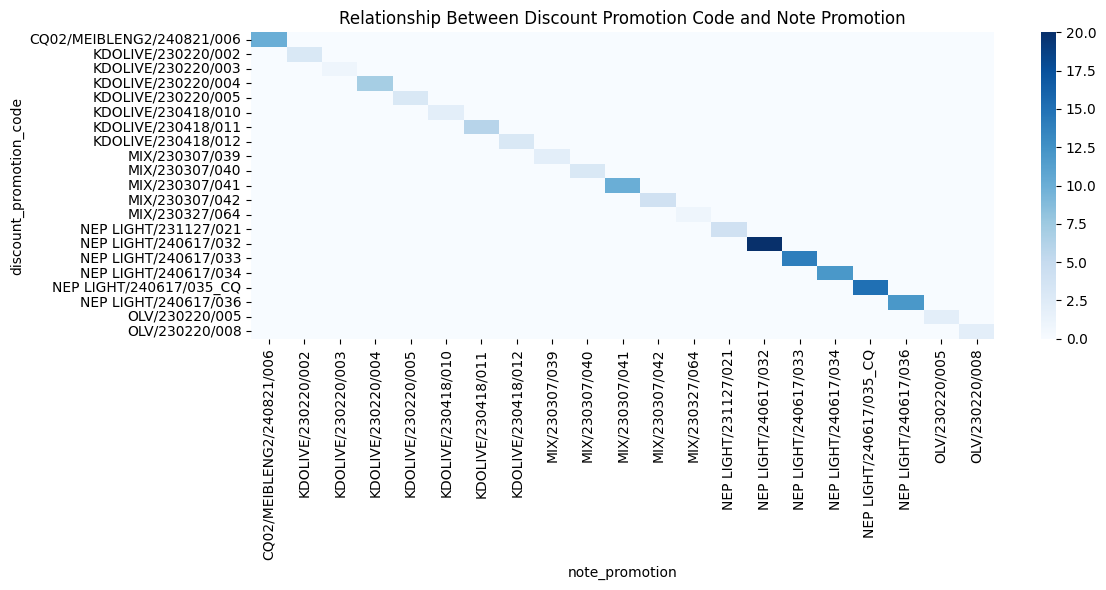

In [27]:
#Vẽ heatmap cho bảng crosstab promotion để dễ nhìn -> Confirm 2 cột promotion có mối liên hệ. Đa số record hoặc không có KM gì, hoặc có cả 2 loại KM
plt.figure(figsize=(12, 6))
sns.heatmap(promo_crosstab, cmap='Blues', cbar=True)
plt.title('Relationship Between Discount Promotion Code and Note Promotion')
plt.xlabel('note_promotion')
plt.ylabel('discount_promotion_code')
plt.tight_layout()
plt.show()

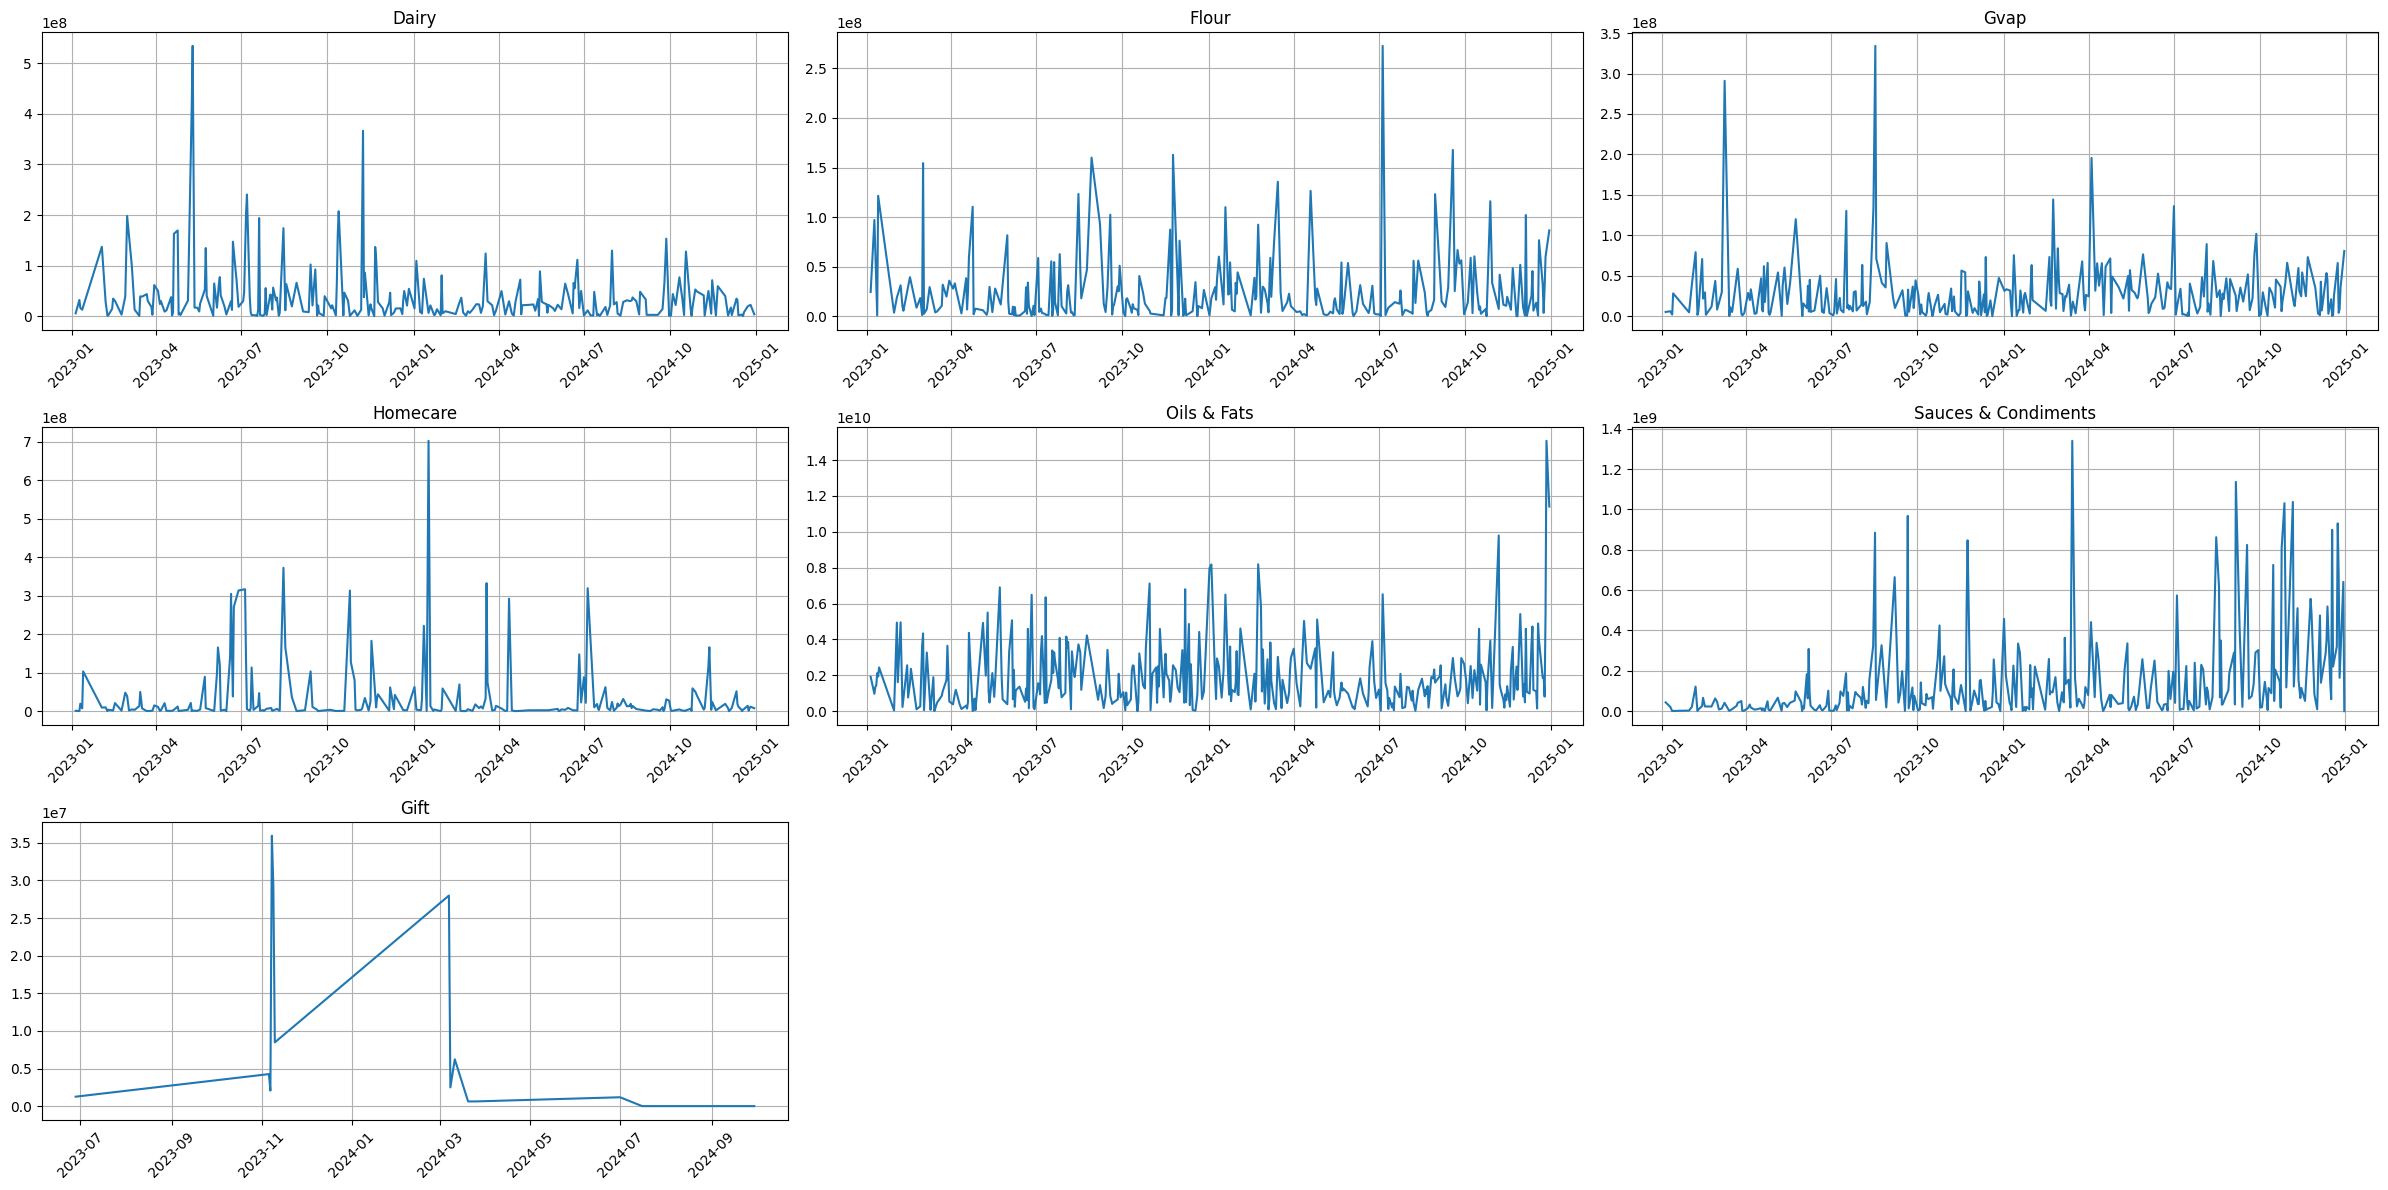

In [28]:
df_grouped = df.groupby(['bill_date', 'entity'])['cost'].sum().reset_index()

entities = df_grouped['entity'].unique()

fig, axes = plt.subplots(3, 3, figsize=(24, 12))
axes = axes.flatten()

for i, entity in enumerate(entities):
    subset = df_grouped[df_grouped['entity'] == entity]
    axes[i].plot(subset['bill_date'], subset['cost'], linestyle='-')
    axes[i].set_title(entity)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True)

for j in range(len(entities), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Feature Engineering

In [29]:
#Qua EDA thấy 'Gift' không phải ngành hàng chính, data ít và không có pattern rõ, sẽ gây nhiễu cho model -> Loại
df = df.drop(df[df['entity'] == "Gift"].index)

In [30]:
#Convert promotion columns thành binary 0/1, chỉ cần biết có KM hay không -> Đơn giản hóa thông tin promotion

df['discount_promotion_code'] = df['discount_promotion_code'].apply(lambda x: 0 if pd.isna(x) else 1)
df['note_promotion'] = df['note_promotion'].apply(lambda x: 0 if pd.isna(x) else 1)

In [31]:
#Mỗi ngày 1 product có thể có nhiều transaction, cần gộp lại thành 1 dòng. Tạo thêm average_unit_price vì unit_price gốc sẽ bị drop khi aggregate
agg_df = df.groupby(['bill_date', 'product'], as_index=False).agg({
    'unit': 'sum', 
    'note_promotion': 'max', 
    'discount_promotion_code': 'max',
    'cost': 'sum'
})
agg_df['average_unit_price'] = agg_df['cost'] / agg_df['unit']

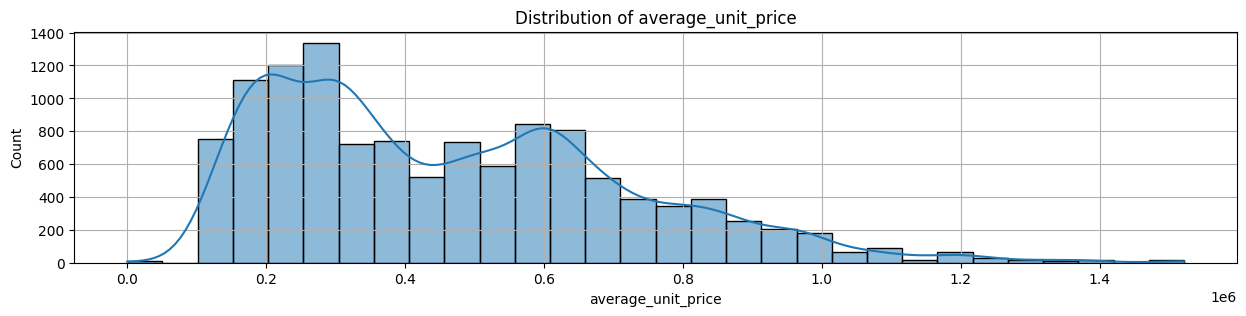

In [32]:
#Plot histogram để kiểm tra distribution của feature mới
# -> Phân bố hợp lý, có một số giá rất cao (outlier) nhưng đa phần tập trung trong khoảng nhất định
plt.figure(figsize=(15, 3))
sns.histplot(agg_df['average_unit_price'], bins=30, kde=True)
plt.title(f'Distribution of average_unit_price')
plt.grid(True)
plt.show()

In [33]:
#Xem summary statistics của data đã gộp
agg_df.describe()

,bill_date,unit,note_promotion,discount_promotion_code,cost,average_unit_price
count,11962,11962.000000,11962.000000,11962.000000,1.196200e+04,1.196200e+04
mean,2024-01-20 05:38:37.940143872,111.439224,0.201722,0.252884,6.109507e+07,4.663725e+05
min,2023-01-05 00:00:00,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,2023-07-21 00:00:00,3.000000,0.000000,0.000000,1.235629e+06,2.527200e+05
50%,2024-01-19 00:00:00,9.000000,0.000000,0.000000,3.635280e+06,4.173120e+05
75%,2024-07-24 00:00:00,33.000000,0.000000,1.000000,1.471012e+07,6.282867e+05
max,2024-12-31 00:00:00,14448.000000,1.000000,1.000000,9.159454e+09,1.521472e+06
std,NaN,516.145218,0.401303,0.434683,3.085465e+08,2.557773e+05


In [34]:
#DDetect oulier trên data gộp -> Tính z-score rolling 30 ngày theo product -> Số outlier tương tự data gốc
agg_df['rolling_mean'] = agg_df.groupby('product')['unit'].transform(lambda x: x.rolling(30, center=True).mean())
agg_df['rolling_std']  = agg_df.groupby('product')['unit'].transform(lambda x: x.rolling(30, center=True).std())
agg_df['z_score'] = (agg_df['unit'] - agg_df['rolling_mean']) / agg_df['rolling_std']

outliers = agg_df[agg_df['z_score'].abs() > 3]
print(f"Detected {len(outliers)} outlier rows (z-score > 3)")

Detected 246 outlier rows (z-score > 3)


In [35]:
#Tạo cột is_outlier binary -> Mục đích để flag outlier thành 1 feature để model biết ngày đó có bất thường không, thay vì xóa outlier
agg_df['is_outlier'] = (agg_df['z_score'].abs() > 3).astype(int)

In [36]:
agg_df

,bill_date,product,unit,note_promotion,discount_promotion_code,cost,average_unit_price,rolling_mean,rolling_std,z_score,is_outlier
0,2023-01-05,BLACK SAUCE 250G X 24 BOT,1,0,0,252120,252120.0,NaN,NaN,NaN,0
1,2023-01-05,CO-0.25L X 12 BTL,6,0,0,3247200,541200.0,NaN,NaN,NaN,0
2,2023-01-05,CO-A 1L X 12 BTL,7,0,0,3668280,524040.0,NaN,NaN,NaN,0
3,2023-01-05,CO-A 2L X 6 BTL,4,0,0,2096160,524040.0,NaN,NaN,NaN,0
4,2023-01-05,CO-A 5L X 4 BTL,16,0,0,13692800,855800.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...
11957,2024-12-30,"UHT LOW FAT MILK 1LX12, NEW ZEALAND ORIGIN",2,0,0,983404,491702.0,NaN,NaN,NaN,0
11958,2024-12-30,UHT LOW FAT PURE MILK 200MLX3X8 TUB IN CARTON,1,0,0,299376,299376.0,NaN,NaN,NaN,0
11959,2024-12-30,VEG MACARONI ELBOW 200G X 24BAG,2,0,0,497664,248832.0,NaN,NaN,NaN,0
11960,2024-12-30,VIETNAMESE PANCAKE MIX 400G*12BAG,15,0,0,2602626,173508.4,NaN,NaN,NaN,0


In [37]:
#Kiểm tra lại data types và null count sau feature engineering -> Một số cột rolling có null
agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11962 entries, 0 to 11961
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   bill_date                11962 non-null  datetime64[ns]
 1   product                  11962 non-null  object        
 2   unit                     11962 non-null  int64         
 3   note_promotion           11962 non-null  int64         
 4   discount_promotion_code  11962 non-null  int64         
 5   cost                     11962 non-null  int64         
 6   average_unit_price       11962 non-null  float64       
 7   rolling_mean             8513 non-null   float64       
 8   rolling_std              8513 non-null   float64       
 9   z_score                  8513 non-null   float64       
 10  is_outlier               11962 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(5), object(1)
memory usage: 1.0+ MB


In [38]:
#Tạo time features + Vietnam holidays -> Time series cần các feature thời gian: day, month, year, day_of_week, week. Thêm holidays vì ngày lễ ảnh hưởng hành vi mua hàng
agg_df['day'] = agg_df['bill_date'].dt.day
agg_df['month'] = agg_df['bill_date'].dt.month
agg_df['year'] = agg_df['bill_date'].dt.year
agg_df['day_of_week'] = agg_df['bill_date'].dt.dayofweek
agg_df['week'] = agg_df['bill_date'].dt.isocalendar().week

vietnam_holidays = pd.DataFrame({
    "Date": pd.to_datetime([
        # 2023 Holidays
        "2023-01-01", "2023-01-20", "2023-01-21", "2023-01-22", "2023-01-23", "2023-01-24",  
        "2023-04-30", "2023-05-01", "2023-09-02",  

        # 2024 Holidays
        "2024-01-01", "2024-02-08", "2024-02-09", "2024-02-10", "2024-02-11", "2024-02-12",  
        "2024-04-30", "2024-05-01", "2024-09-02",  

        # 2025 Holidays
        "2025-01-01", "2025-01-28", "2025-01-29", "2025-01-30", "2025-01-31", "2025-02-01",  
        "2025-04-30", "2025-05-01", "2025-09-02"
    ])
})

def is_holiday_week(date):
    return any((holiday - date).days in range(1, 8) for holiday in vietnam_holidays["Date"])

agg_df["holiday_week"] = agg_df["bill_date"].apply(is_holiday_week).astype(int)

In [39]:
#Kiểm tra lại số unique values sau khi thêm nhiều features -> Các time features có unique values đúng như thực tế (month: 12, day_of_week: 7)

c = agg_df.nunique()
c

bill_date                   360
product                     132
unit                        875
note_promotion                2
discount_promotion_code       2
cost                       5792
average_unit_price         2305
rolling_mean               3807
rolling_std                8110
z_score                    8474
is_outlier                    2
day                          31
month                        12
year                          2
day_of_week                   7
week                         52
holiday_week                  2
dtype: int64

In [40]:
#Drop cột cost, rolling_mean, rolling_std, z_score do cost correlate quá cao với unit (target) -> data leakage. rolling stats đã được dùng để tạo is_outlier, không cần giữ
agg_df = agg_df.drop(columns = (['cost', 'rolling_mean','rolling_std','z_score']), axis =1)

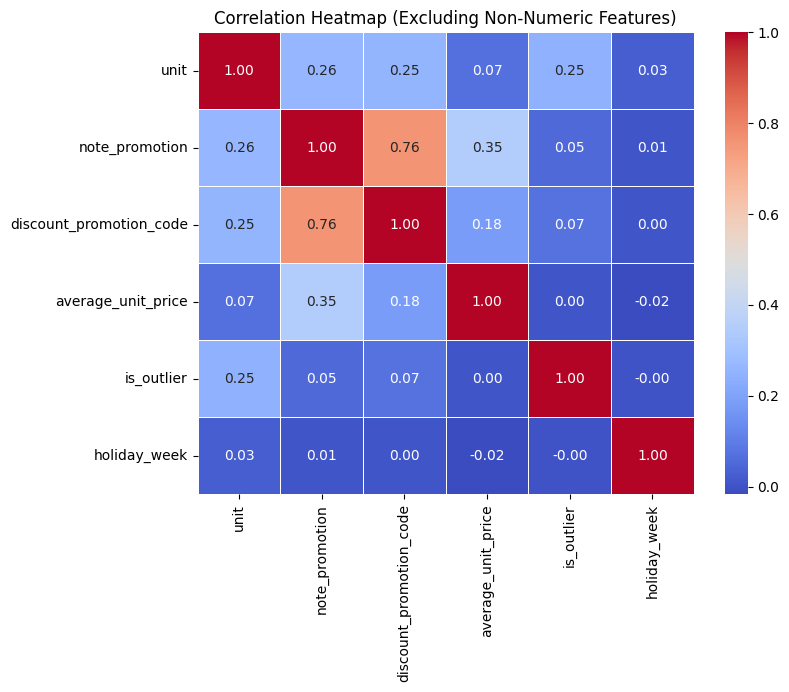

In [41]:
#Vẽ heatmap correlation cho data sau feature engineering -> Không còn feature nào correlate quá cao với nhau (trừ với target). Các features khá independent -> tốt cho model
df_numeric = agg_df.drop(['product','bill_date','week','day','month','year','day_of_week'], axis =1)

corr_matrix = df_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Excluding Non-Numeric Features)")
plt.show()

In [42]:
#LabelEncoder cho product -> Dùng LabelEncoder biến product name thành số. Lưu mapping để decode sau
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

agg_df['product_encoded'] = le.fit_transform(agg_df['product'])
sku_mapping = dict(zip(le.classes_, range(len(le.classes_))))
sku_inverse_mapping = dict(zip(range(len(le.classes_)), le.classes_))

In [43]:
#Set bill_date làm index + sort do Time series cần data được sort theo thời gian và có datetime index
agg_df.set_index('bill_date', inplace=True)
agg_df.sort_index(inplace=True)

In [44]:
#Tạo Lag, Rolling, Expanding, Fourier features -> lag features nắm bắt past values, rolling nắm trend gần, Fourier nắm seasonality
#Tạo được nhiều features mạnh cho time series. Lag_1 thường là feature quan trọng nhất. Fourier giúp capture chu kỳ tuần/tháng
for lag in [1, 7, 14, 30, 90]:  
    agg_df[f'Lag_{lag}'] = agg_df.groupby('product_encoded')['unit'].shift(lag)

# Rolling Mean & Standard Deviation
for window in [7, 14, 30]:
    agg_df[f'Rolling_Mean_{window}'] = agg_df.groupby('product_encoded')['unit'].transform(lambda x: x.rolling(window).mean())
    agg_df[f'Rolling_Std_{window}'] = agg_df.groupby('product_encoded')['unit'].transform(lambda x: x.rolling(window).std())

# Expanding Mean
agg_df['Expanding_Mean'] = agg_df.groupby('product_encoded')['unit'].transform(lambda x: x.expanding().mean())

# Fourier Features for Seasonality
from numpy import pi
agg_df['Fourier_Sin_7'] = np.sin(2 * pi * agg_df['day_of_week'] / 7)
agg_df['Fourier_Cos_7'] = np.cos(2 * pi * agg_df['day_of_week'] / 7)
agg_df['Fourier_Sin_30'] = np.sin(2 * pi * agg_df['day'] / 30)
agg_df['Fourier_Cos_30'] = np.cos(2 * pi * agg_df['day'] / 30)

agg_df.fillna(0, inplace=True)

In [45]:
#Loại bỏ cột product dạng text, giữ product_encoded dạng số
#Đã tạo được bộ features phong phú gồm price, promotion binary, outlier flag, time features, lag/rolling/Fourier. Data sẵn sàng cho modeling
agg_df.drop(columns=['product'], inplace=True)
agg_df.head()

,unit,note_promotion,discount_promotion_code,average_unit_price,is_outlier,day,month,year,day_of_week,week,...,Rolling_Std_7,Rolling_Mean_14,Rolling_Std_14,Rolling_Mean_30,Rolling_Std_30,Expanding_Mean,Fourier_Sin_7,Fourier_Cos_7,Fourier_Sin_30,Fourier_Cos_30
bill_date,,,,,,,,,,,,,,,,,,,,,
2023-01-05,1,0,0,252120.0,0,5,1,2023,3,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.433884,-0.900969,0.866025,0.5
2023-01-05,6,0,0,541200.0,0,5,1,2023,3,1,...,0.0,0.0,0.0,0.0,0.0,6.0,0.433884,-0.900969,0.866025,0.5
2023-01-05,7,0,0,524040.0,0,5,1,2023,3,1,...,0.0,0.0,0.0,0.0,0.0,7.0,0.433884,-0.900969,0.866025,0.5
2023-01-05,4,0,0,524040.0,0,5,1,2023,3,1,...,0.0,0.0,0.0,0.0,0.0,4.0,0.433884,-0.900969,0.866025,0.5
2023-01-05,16,0,0,855800.0,0,5,1,2023,3,1,...,0.0,0.0,0.0,0.0,0.0,16.0,0.433884,-0.900969,0.866025,0.5


In [46]:
agg_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11962 entries, 2023-01-05 to 2024-12-31
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   unit                     11962 non-null  int64  
 1   note_promotion           11962 non-null  int64  
 2   discount_promotion_code  11962 non-null  int64  
 3   average_unit_price       11962 non-null  float64
 4   is_outlier               11962 non-null  int64  
 5   day                      11962 non-null  int32  
 6   month                    11962 non-null  int32  
 7   year                     11962 non-null  int32  
 8   day_of_week              11962 non-null  int32  
 9   week                     11962 non-null  UInt32 
 10  holiday_week             11962 non-null  int64  
 11  product_encoded          11962 non-null  int64  
 12  Lag_1                    11962 non-null  float64
 13  Lag_7                    11962 non-null  float64
 14  Lag_1

# Time Series Split

In [47]:
#Liệt kê tất cả features sẽ dùng, setup TimeSeriesSplit 5 folds đảm bảo train luôn trước test theo thời gian
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

features = ['product_encoded', 'average_unit_price', 
            'note_promotion','discount_promotion_code', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_30', 'Lag_90',
            'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_Mean_30',
            'Rolling_Std_7', 'Rolling_Std_14', 'Rolling_Std_30', 'Expanding_Mean',
            'Fourier_Sin_7', 'Fourier_Cos_7', 'Fourier_Sin_30', 'Fourier_Cos_30',
            'day', 'month', 'year', 'day_of_week', 'week','holiday_week','is_outlier'
           ]
target = 'unit'

tscv = TimeSeriesSplit(n_splits=5)

# Exp1: XGBoost

In [48]:
#Train XGBoost với default params qua 5 folds, thu thập MAE, MSE, R² mỗi fold
#MAE trung bình khoảng 109, R² khoảng 39%. Model đã học được pattern nhưng chưa tốt lắm. R² dao động nhiều giữa các fold
mae_scores1 = []
mse_scores1 = []
r2_scores1 = []
fold1 = 1

for train_index, test_index in tscv.split(agg_df):
    train, test = agg_df.iloc[train_index], agg_df.iloc[test_index]
    print(f"Fold {fold1}: Train Size: {len(train)}, Test Size: {len(test)}")
    
    model1 = XGBRegressor(n_estimators=100, learning_rate=0.1)
    model1.fit(train[features], train[target])
    
    predictions = model1.predict(test[features])
    
    mae1 = mean_absolute_error(test[target], predictions)
    mse1 = mean_squared_error(test[target], predictions)
    r21 = r2_score(test[target], predictions)
    mae_scores1.append(mae1)
    r2_scores1.append(r21)
    mse_scores1.append(mse1)
    
    print(f"Fold {fold1} MAE: {mae1}")
    print(f"Fold {fold1} R²: {r21}")
    print(f"Fold {fold1} MSE: {mse1}\n")
    fold1 += 1

print("Average MAE:", np.mean(mae_scores1))
print("Average R²:", np.mean(r2_scores1))
print("Average MSE:", np.mean(mse_scores1))

Fold 1: Train Size: 1997, Test Size: 1993
Fold 1 MAE: 128.19021606445312
Fold 1 R²: 0.3241981863975525
Fold 1 MSE: 169062.125

Fold 2: Train Size: 3990, Test Size: 1993
Fold 2 MAE: 124.38774871826172
Fold 2 R²: 0.509070098400116
Fold 2 MSE: 168190.359375

Fold 3: Train Size: 5983, Test Size: 1993
Fold 3 MAE: 120.28716278076172
Fold 3 R²: 0.25742167234420776
Fold 3 MSE: 170260.828125

Fold 4: Train Size: 7976, Test Size: 1993
Fold 4 MAE: 66.0870361328125
Fold 4 R²: 0.44770383834838867
Fold 4 MSE: 55463.51171875

Fold 5: Train Size: 9969, Test Size: 1993
Fold 5 MAE: 106.19355010986328
Fold 5 R²: 0.41965538263320923
Fold 5 MSE: 239058.5

Average MAE: 109.02914276123047
Average R²: 0.3916098356246948
Average MSE: 160407.06484375


In [49]:
#Tính PSI để đo mức độ thay đổi phân bố giữa train và test
def calculate_psi(expected, actual, buckets=10):
    def scale_range(series):
        return np.clip(series, np.nanpercentile(series, 0.1), np.nanpercentile(series, 99.9))

    expected, actual = scale_range(expected), scale_range(actual)
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))

    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    psi = np.sum((expected_percents - actual_percents) * np.log((expected_percents + 1e-6) / (actual_percents + 1e-6)))
    return psi

ks_results = {}
psi_results = {}

for col in features:
    ks_stat = ks_2samp(train[col], test[col]).statistic
    psi_val = calculate_psi(train[col], test[col])
    ks_results[col] = ks_stat
    psi_results[col] = psi_val

stability_df = pd.DataFrame({
    'Feature': features,
    'KS': [ks_results[col] for col in features],
    'PSI': [psi_results[col] for col in features]
}).sort_values(by='PSI', ascending=False)

print(stability_df)

                    Feature        KS        PSI
21                    month  0.791052  10.528257
24                     week  0.814211   9.299941
22                     year  0.562745   7.916588
6                    Lag_14  0.157883   0.414700
8                    Lag_90  0.294446   0.284602
18           Fourier_Sin_30  0.128542   0.250383
5                     Lag_7  0.083155   0.240310
13           Rolling_Std_14  0.150261   0.208538
15           Expanding_Mean  0.122515   0.144523
7                    Lag_30  0.170868   0.143058
1        average_unit_price  0.109128   0.133738
20                      day  0.147381   0.132387
11          Rolling_Mean_30  0.172075   0.121200
0           product_encoded  0.079807   0.118331
14           Rolling_Std_30  0.175878   0.108585
10          Rolling_Mean_14  0.149458   0.095622
19           Fourier_Cos_30  0.094827   0.092701
16            Fourier_Sin_7  0.046029   0.078002
9            Rolling_Mean_7  0.071219   0.077892
12            Rollin

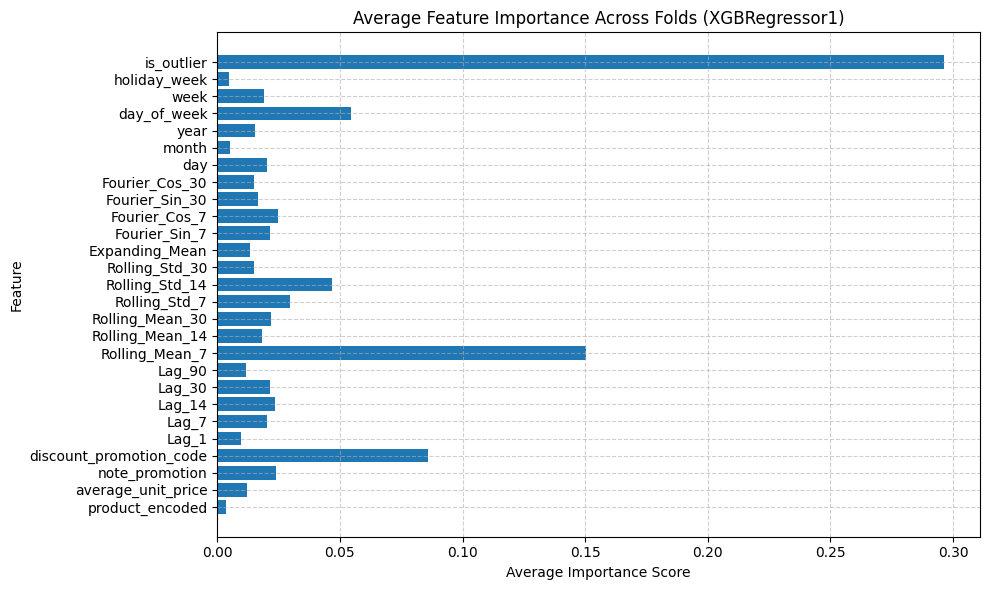

In [50]:
#Feature importance plot cho XGB1
# -> Các outlier và  Rolling_mean)7 đang là cao nhất
feature_importance_list = []

feature_importance_list.append(model1.feature_importances_)

importances_array = np.array(feature_importance_list)

avg_importance = importances_array.mean(axis=0)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(features, avg_importance)
plt.title("Average Feature Importance Across Folds (XGBRegressor1)")
plt.xlabel("Average Importance Score")
plt.ylabel("Feature")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [51]:
#Tính std và stability index cho MAE, MSE, R² qua 5 folds -> Std khá cao -> model chưa ổn định lắm, performance dao động giữa các folds. Cần fine-tune.
print("Metric Stability Across Folds:")
print(f"MAE Std: {np.std(mae_scores1):.4f}")
print(f"MSE Std: {np.std(mse_scores1):.4f}")
print(f"R² Std:  {np.std(r2_scores1):.4f}")

def stability_index(metric_list):
    return np.std(metric_list) / (np.mean(metric_list) + 1e-6)

print(f"MAE Stability Index: {stability_index(mae_scores1):.4f}")
print(f"R² Stability Index:  {stability_index(r2_scores1):.4f}")

Metric Stability Across Folds:
MAE Std: 22.7237
MSE Std: 59045.3791
R² Std:  0.0898
MAE Stability Index: 0.2084
R² Stability Index:  0.2292


# Exp2: RandomForestRegressor

In [52]:
#Train RF với default params qua 5 folds, thu thập MAE, MSE, R²
#-> MAE khoảng 115, R² khoảng 42%. RF có R² cao hơn XGB1 một chút nhưng MAE cũng cao hơn. Kết quả khá tương đương
mae_scores2 = []
mse_scores2 = []
r2_scores2 = []
fold2 = 1

for train_index, test_index in tscv.split(agg_df):
    train, test = agg_df.iloc[train_index], agg_df.iloc[test_index]
    print(f"Fold {fold2}: Train Size: {len(train)}, Test Size: {len(test)}")
    
    model2 = RandomForestRegressor(n_estimators=100)
    model2.fit(train[features], train[target])
    
    predictions = model2.predict(test[features])
    
    mae2 = mean_absolute_error(test[target], predictions)
    mse2 = mean_squared_error(test[target], predictions)
    r22 = r2_score(test[target], predictions)
    mae_scores2.append(mae2)
    r2_scores2.append(r22)
    mse_scores2.append(mse2)
    
    print(f"Fold {fold2} MAE: {mae2}")
    print(f"Fold {fold2} R²: {r22}")
    print(f"Fold {fold2} MSE: {mse2}\n")
    fold2 += 1

print("Average MAE:", np.mean(mae_scores2))
print("Average R²:", np.mean(r2_scores2))
print("Average MSE:", np.mean(mse_scores2))

Fold 1: Train Size: 1997, Test Size: 1993
Fold 1 MAE: 144.90865529352732
Fold 1 R²: 0.28943796787813125
Fold 1 MSE: 177757.912361716

Fold 2: Train Size: 3990, Test Size: 1993
Fold 2 MAE: 140.36021575514297
Fold 2 R²: 0.4863538803143813
Fold 2 MSE: 175972.8300289513

Fold 3: Train Size: 5983, Test Size: 1993
Fold 3 MAE: 114.88927747114903
Fold 3 R²: 0.39868674484474487
Fold 3 MSE: 137871.10066969393

Fold 4: Train Size: 7976, Test Size: 1993
Fold 4 MAE: 64.34033617661817
Fold 4 R²: 0.551826109788179
Fold 4 MSE: 45007.19329678876

Fold 5: Train Size: 9969, Test Size: 1993
Fold 5 MAE: 110.7139136979428
Fold 5 R²: 0.44840886939388735
Fold 5 MSE: 227214.22452538885

Average MAE: 115.04247967887605
Average R²: 0.43494271444386473
Average MSE: 152764.65217650775


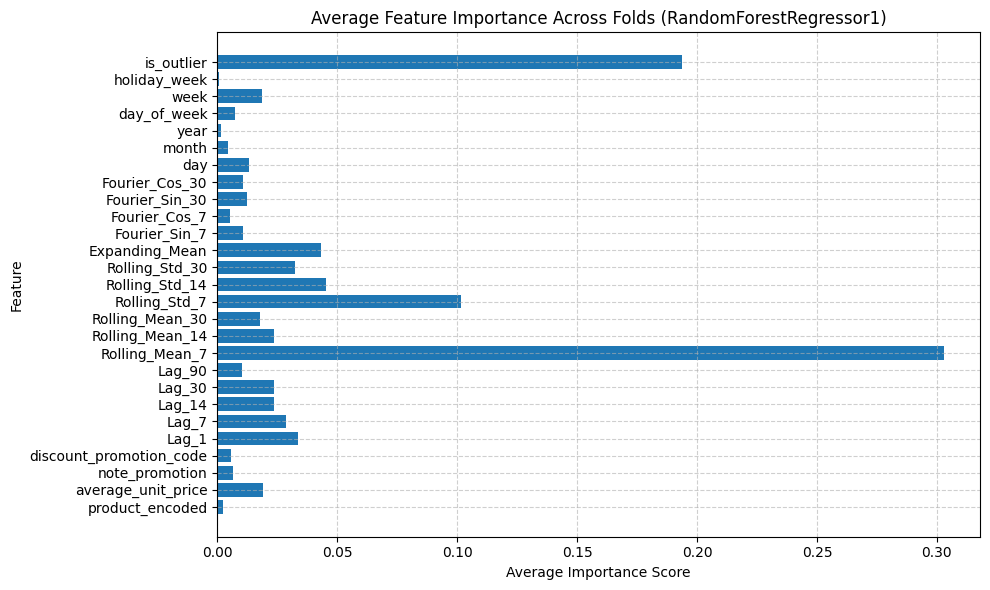

In [53]:
#Tương tự, RF cũng coi các outlier và Rolling_mean_7 là quan trọng nhất, tương tự XGB1. Tuy nhiên thứ tự có khác đôi chút
feature_importance_list = []

feature_importance_list.append(model2.feature_importances_)

importances_array = np.array(feature_importance_list)

avg_importance = importances_array.mean(axis=0)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(features, avg_importance)
plt.title("Average Feature Importance Across Folds (RandomForestRegressor1)")
plt.xlabel("Average Importance Score")
plt.ylabel("Feature")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [54]:
#Kiểm tra stability của RF1 tương tự như đã làm với XGB1 -> RF1 stability tương tự XGB1, cũng dao động đáng kể giữa các folds
print("Metric Stability Across Folds:")
print(f"MAE Std: {np.std(mae_scores2):.4f}")
print(f"MSE Std: {np.std(mse_scores2):.4f}")
print(f"R² Std:  {np.std(r2_scores2):.4f}")

def stability_index(metric_list):
    return np.std(metric_list) / (np.mean(metric_list) + 1e-6)

print(f"MAE Stability Index: {stability_index(mae_scores2):.4f}")
print(f"R² Stability Index:  {stability_index(r2_scores2):.4f}")

Metric Stability Across Folds:
MAE Std: 28.7139
MSE Std: 60892.5434
R² Std:  0.0883
MAE Stability Index: 0.2496
R² Stability Index:  0.2030


In [55]:
#So sánh trực tiếp 2 model cùng một bảng để dễ đánh giá -> XGB MAE thấp hơn, RF R² cao hơn một chút. Nhìn chung 2 model khá ngang nhau ở baseline trước fine-tune
fold_results = []
for fold_idx in range(len(mae_scores1)):
    fold_results.append({
        'Fold': fold_idx + 1,
        'XGB_MAE': mae_scores1[fold_idx],
        'XGB_R2': r2_scores1[fold_idx],
        'XGB_MSE': mse_scores1[fold_idx],
        'RF_MAE': mae_scores2[fold_idx],
        'RF_R2': r2_scores2[fold_idx],
        'RF_MSE': mse_scores2[fold_idx],
    })

comparison_df = pd.DataFrame(fold_results)

avg_row = {
    'Fold': 'Average',
    'XGB_MAE': np.mean(mae_scores1),
    'XGB_R2': np.mean(r2_scores1),
    'XGB_MSE': np.mean(mse_scores1),
    'RF_MAE': np.mean(mae_scores2),
    'RF_R2': np.mean(r2_scores2),
    'RF_MSE': np.mean(mse_scores2)
}

avg_df = pd.DataFrame([avg_row])
comparison_df = pd.concat([comparison_df, avg_df], ignore_index=True)

print(comparison_df)

      Fold     XGB_MAE    XGB_R2        XGB_MSE      RF_MAE     RF_R2  \
0        1  128.190216  0.324198  169062.125000  144.908655  0.289438   
1        2  124.387749  0.509070  168190.359375  140.360216  0.486354   
2        3  120.287163  0.257422  170260.828125  114.889277  0.398687   
3        4   66.087036  0.447704   55463.511719   64.340336  0.551826   
4        5  106.193550  0.419655  239058.500000  110.713914  0.448409   
5  Average  109.029143  0.391610  160407.064844  115.042480  0.434943   

          RF_MSE  
0  177757.912362  
1  175972.830029  
2  137871.100670  
3   45007.193297  
4  227214.224525  
5  152764.652177  


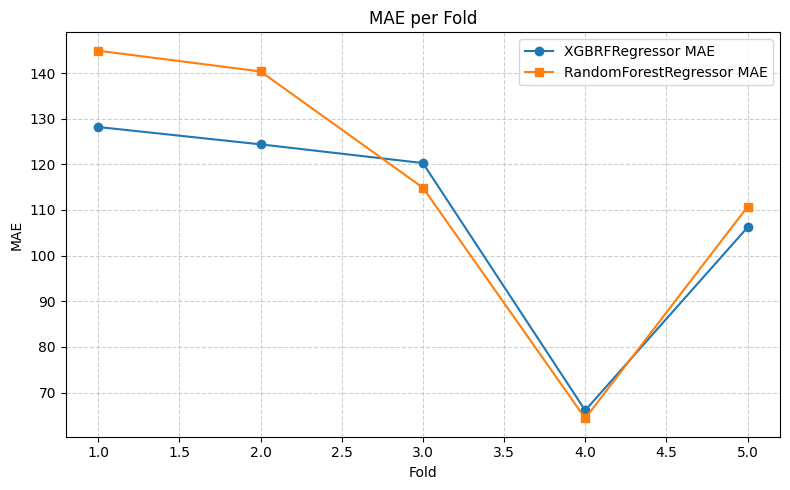

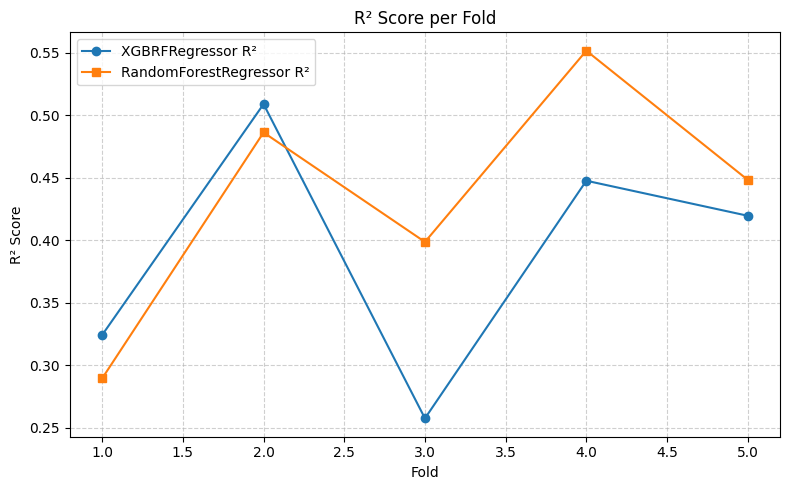

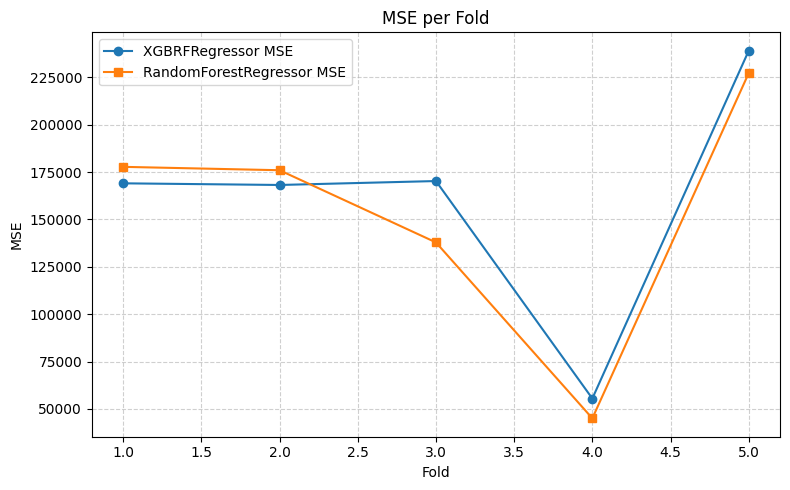

In [56]:
#Visualize sự so sánh cho dễ nhìn hơn bảng số -> Thấy rõ fold nào model nào tốt hơn. Cả 2 model đều có fold 4 tốt nhất
# -> Kết luận Exp1 vs Exp2: 2 model baseline cho kết quả tương đương. Cần fine-tune hyperparameters để cải thiện
fold_only_df = comparison_df[comparison_df['Fold'] != 'Average']

# Plot MAE
plt.figure(figsize=(8, 5))
plt.plot(fold_only_df['Fold'], fold_only_df['XGB_MAE'], marker='o', label='XGBRFRegressor MAE')
plt.plot(fold_only_df['Fold'], fold_only_df['RF_MAE'], marker='s', label='RandomForestRegressor MAE')
plt.title('MAE per Fold')
plt.xlabel('Fold')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot R²
plt.figure(figsize=(8, 5))
plt.plot(fold_only_df['Fold'], fold_only_df['XGB_R2'], marker='o', label='XGBRFRegressor R²')
plt.plot(fold_only_df['Fold'], fold_only_df['RF_R2'], marker='s', label='RandomForestRegressor R²')
plt.title('R² Score per Fold')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot MSE
plt.figure(figsize=(8, 5))
plt.plot(fold_only_df['Fold'], fold_only_df['XGB_MSE'], marker='o', label='XGBRFRegressor MSE')
plt.plot(fold_only_df['Fold'], fold_only_df['RF_MSE'], marker='s', label='RandomForestRegressor MSE')
plt.title('MSE per Fold')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Fine-tuning

## XGBoostRegressor

In [57]:
#Cần tìm tổ hợp hyperparameters tốt nhất thay vì dùng default. GridSearch thử tất cả combinations
#Tìm được best params cho XGB. GridSearch dùng TimeSeriesSplit làm CV strategy nên kết quả đáng tin cậy
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    n_jobs=-1
)

xgb_grid_search.fit(agg_df[features], agg_df[target])
print("Best Params:", xgb_grid_search.best_params_)
print("Best Score:", -xgb_grid_search.best_score_)

Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Best Score: 106.69276428222656


## RandomForestRegressor

In [58]:
#Tương tự XGB, cần tìm best params cho RF
param_grid_rdf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rdf_grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid_rdf,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    n_jobs=-1
)

rdf_grid_search.fit(agg_df[features], agg_df[target])
print("Best Params:", rdf_grid_search.best_params_)
print("Best Score:", -rdf_grid_search.best_score_)

Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 110.51769622424995


# Retrain and Comparison

## Exp3: XGBoostRegressor

In [59]:
#Train XGB với best params từ GridSearch -> MAE ~107 (giảm từ 109), R² ~45.7% (tăng từ 39%). Cải thiện rõ rệt nhờ fine-tuning
mae_scores3 = []
r2_scores3 = []
mse_scores3 = []
fold3 = 1

for train_index, test_index in tscv.split(agg_df):
    train, test = agg_df.iloc[train_index], agg_df.iloc[test_index]
    print(f"Fold {fold3}: Train Size: {len(train)}, Test Size: {len(test)}")
    
    model3 = XGBRegressor(colsample_bytree= 1.0, learning_rate= 0.05, max_depth= 5, n_estimators= 100, subsample= 0.8)
    model3.fit(train[features], train[target])
    
    predictions = model3.predict(test[features])
    
    mae3 = mean_absolute_error(test[target], predictions)
    r23 = r2_score(test[target], predictions)
    mse3 = mean_squared_error(test[target], predictions)
    mae_scores3.append(mae3)
    r2_scores3.append(r23)
    mse_scores3.append(mse3)
    
    print(f"Fold {fold3} MAE: {mae3}")
    print(f"Fold {fold3} R²: {r23}")
    print(f"Fold {fold3} MSE: {mse3}\n")
    fold3 += 1

print("Average MAE:", np.mean(mae_scores3))
print("Average R²:", np.mean(r2_scores3))
print("Average MSE:", np.mean(mse_scores3))

Fold 1: Train Size: 1997, Test Size: 1993
Fold 1 MAE: 119.30364990234375
Fold 1 R²: 0.4188186526298523
Fold 1 MSE: 145391.359375

Fold 2: Train Size: 3990, Test Size: 1993
Fold 2 MAE: 123.71430969238281
Fold 2 R²: 0.5278184413909912
Fold 2 MSE: 161767.28125

Fold 3: Train Size: 5983, Test Size: 1993
Fold 3 MAE: 119.0683822631836
Fold 3 R²: 0.32460492849349976
Fold 3 MSE: 154856.828125

Fold 4: Train Size: 7976, Test Size: 1993
Fold 4 MAE: 67.5234603881836
Fold 4 R²: 0.5301141738891602
Fold 4 MSE: 47187.578125

Fold 5: Train Size: 9969, Test Size: 1993
Fold 5 MAE: 108.69902801513672
Fold 5 R²: 0.3810678720474243
Fold 5 MSE: 254953.671875

Average MAE: 107.6617660522461
Average R²: 0.43648481369018555
Average MSE: 152831.34375


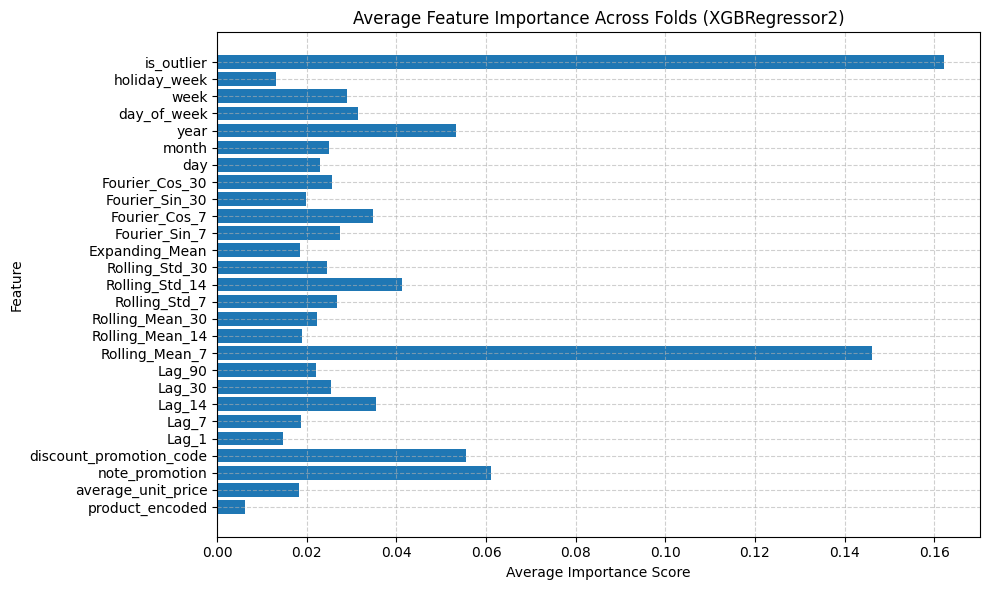

In [60]:
#Xem feature importance có thay đổi sau fine-tune không -> Thứ tự feature importance thay đổi một chút nhưng outlier vẫn đứng top
feature_importance_list = []

feature_importance_list.append(model3.feature_importances_)

importances_array = np.array(feature_importance_list)

avg_importance = importances_array.mean(axis=0)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(features, avg_importance)
plt.title("Average Feature Importance Across Folds (XGBRegressor2)")
plt.xlabel("Average Importance Score")
plt.ylabel("Feature")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

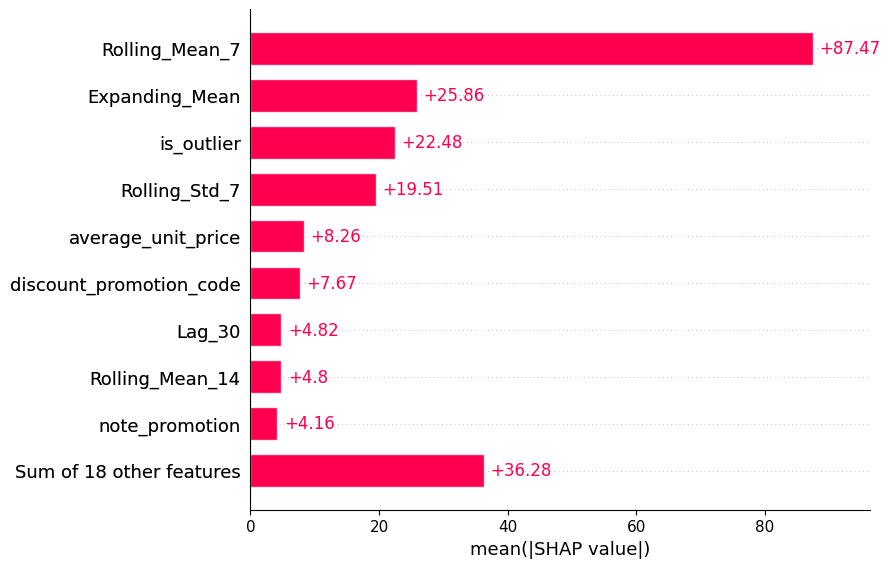

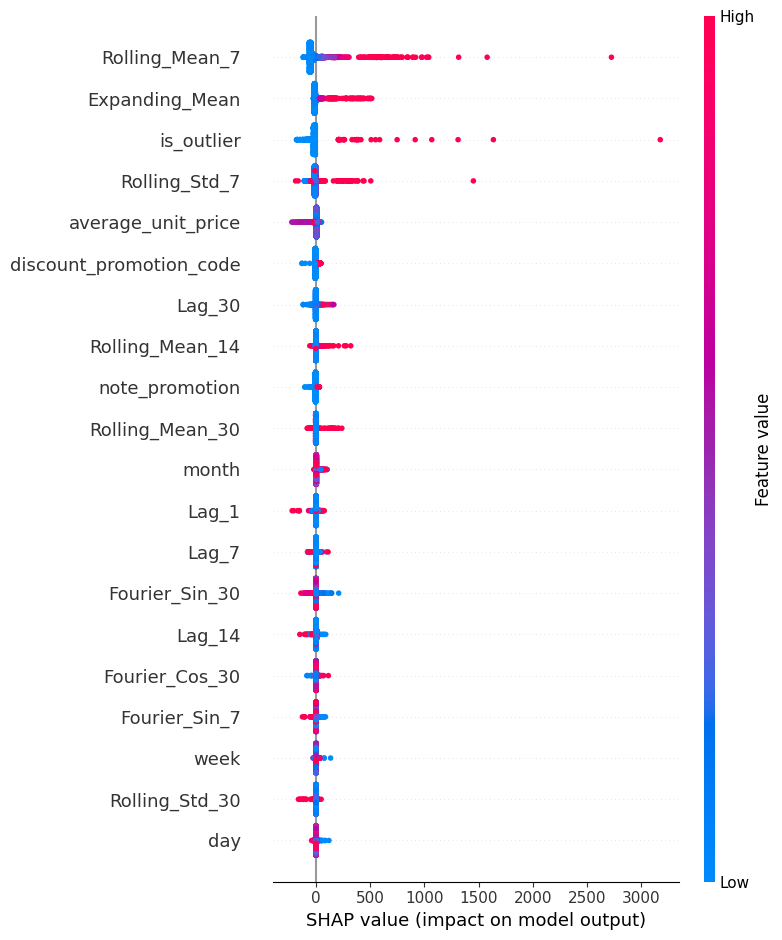

In [61]:
#SHAP values cho XGB2 -> Feature importance chỉ cho biết feature nào quan trọng, SHAP cho biết feature ảnh hưởng theo hướng nào tăng hay giảm prediction
#SHAP cho thấy rõ Rolling_mean_ 7 là quan trọng nhất -trung bình 7 ngày gần nhất ảnh hưởng rất lớn -> Model dự đoán chủ yếu dựa trên momentum ngắn hạn
import shap
X_train_shap = train[features].copy().astype("float64")
X_test_shap = test[features].copy().astype("float64")
X_test_shap = X_test_shap[X_train_shap.columns]

explainer = shap.TreeExplainer(model3)

shap_values = explainer.shap_values(X_test_shap, check_additivity=False)

explanation = shap.Explanation(
    values=shap_values,
    data=X_test_shap,
    feature_names=X_test_shap.columns
)

shap.plots.bar(explanation)
shap.summary_plot(shap_values, X_test_shap, feature_names=X_test_shap.columns)

In [62]:
#Kiểm tra model sau fine-tune có ổn định hơn không -> Stability cải thiện so với baseline. R² std giảm -> model predict ổn định hơn qua các folds
print("Metric Stability Across Folds:")
print(f"MAE Std: {np.std(mae_scores3):.4f}")
print(f"MSE Std: {np.std(mse_scores3):.4f}")
print(f"R² Std:  {np.std(r2_scores3):.4f}")

def stability_index(metric_list):
    return np.std(metric_list) / (np.mean(metric_list) + 1e-6)

print(f"MAE Stability Index: {stability_index(mae_scores3):.4f}")
print(f"R² Stability Index:  {stability_index(r2_scores3):.4f}")

Metric Stability Across Folds:
MAE Std: 20.6663
MSE Std: 65922.5031
R² Std:  0.0813
MAE Stability Index: 0.1920
R² Stability Index:  0.1861


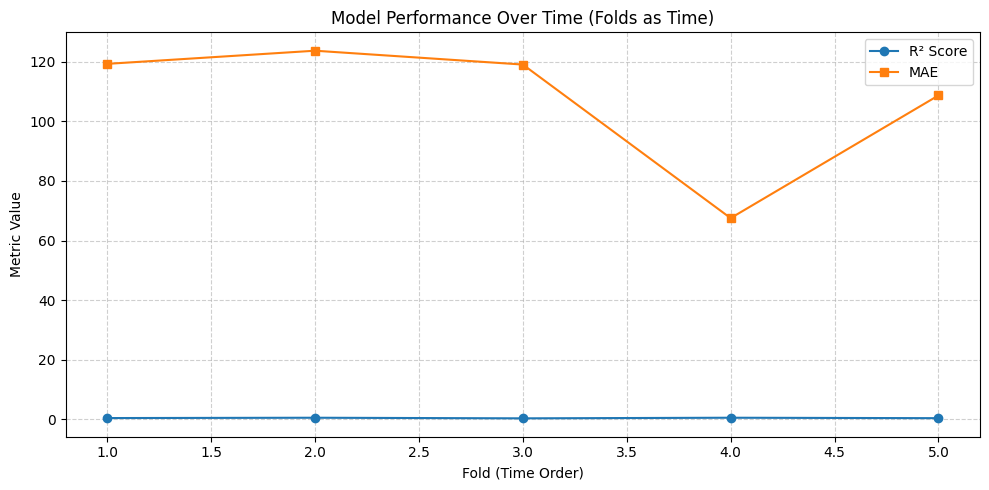

📉 R² decay per fold: -0.0073
📈 MAE increase per fold: -7.7400


In [63]:
folds = list(range(1, len(r2_scores3) + 1))

plt.figure(figsize=(10, 5))
plt.plot(folds, r2_scores3, marker='o', label='R² Score')
plt.plot(folds, mae_scores3, marker='s', label='MAE')
plt.title('Model Performance Over Time (Folds as Time)')
plt.xlabel('Fold (Time Order)')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

X_fold = np.array(folds).reshape(-1, 1)
r2_trend = LinearRegression().fit(X_fold, r2_scores3)
mae_trend = LinearRegression().fit(X_fold, mae_scores3)

r2_slope = r2_trend.coef_[0]
mae_slope = mae_trend.coef_[0]

print(f"📉 R² decay per fold: {r2_slope:.4f}")
print(f"📈 MAE increase per fold: {mae_slope:.4f}")

## Exp4: RandomForestRegressor

In [72]:
#Retrain RF với best params để so sánh với XGB2 -> MAE ~110 (giảm từ 115), R² ~44.0% (tăng từ 43%). RF cũng cải thiện nhờ fine-tuning
mae_scores4 = []
r2_scores4 = []
mse_scores4 = []
fold4 = 1

for train_index, test_index in tscv.split(agg_df):
    train, test = agg_df.iloc[train_index], agg_df.iloc[test_index]
    print(f"Fold {fold4}: Train Size: {len(train)}, Test Size: {len(test)}")
    
    model4 = RandomForestRegressor(max_depth= 10, min_samples_split= 2, n_estimators= 200)
    model4.fit(train[features], train[target])
    
    predictions = model4.predict(test[features])
    
    mae4 = mean_absolute_error(test[target], predictions)
    mse4 = mean_squared_error(test[target], predictions)
    r24 = r2_score(test[target], predictions)
    mae_scores4.append(mae4)
    r2_scores4.append(r24)
    mse_scores4.append(mse4)
    
    print(f"Fold {fold4} MAE: {mae4}")
    print(f"Fold {fold4} R²: {r24}")
    print(f"Fold {fold4} MSE: {mse4}\n")
    fold4 += 1

print("Average MAE:", np.mean(mae_scores4))
print("Average R²:", np.mean(r2_scores4))
print("Average MSE:", np.mean(mse_scores4))

Fold 1: Train Size: 1997, Test Size: 1993
Fold 1 MAE: 141.85743674721363
Fold 1 R²: 0.3002341521795736
Fold 1 MSE: 175057.0824606785

Fold 2: Train Size: 3990, Test Size: 1993
Fold 2 MAE: 134.62721196633305
Fold 2 R²: 0.48675352028869134
Fold 2 MSE: 175835.91518704602

Fold 3: Train Size: 5983, Test Size: 1993
Fold 3 MAE: 106.17411666547628
Fold 3 R²: 0.4796993199155837
Fold 3 MSE: 119296.26833838449

Fold 4: Train Size: 7976, Test Size: 1993
Fold 4 MAE: 62.84965088228494
Fold 4 R²: 0.5576454774406199
Fold 4 MSE: 44422.79199515403

Fold 5: Train Size: 9969, Test Size: 1993
Fold 5 MAE: 108.6275931814847
Fold 5 R²: 0.43641466487042924
Fold 5 MSE: 232154.9382685591

Average MAE: 110.8272018885585
Average R²: 0.4521494269389795
Average MSE: 149353.39924996445


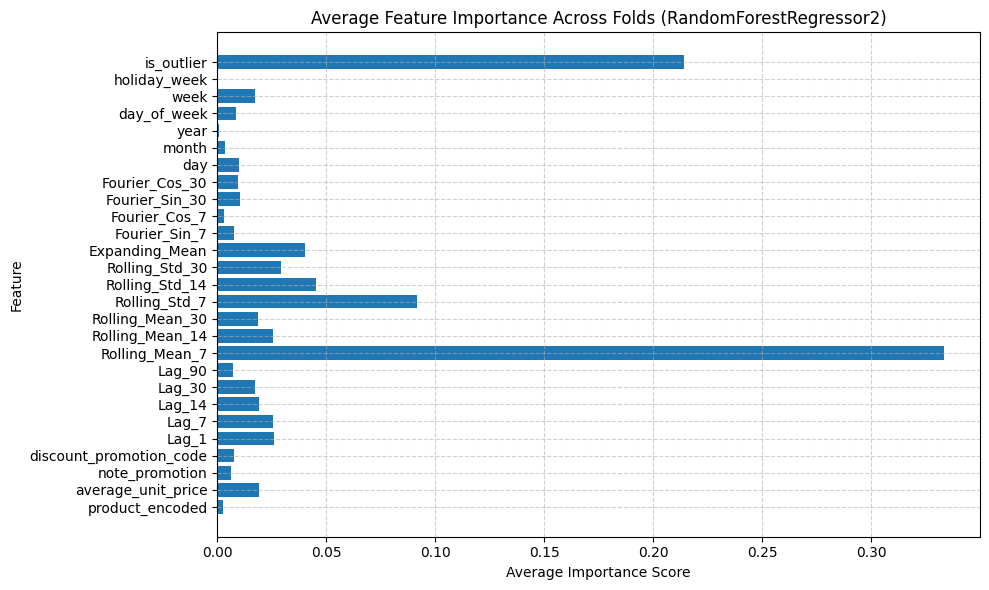

In [73]:
#So sánh feature importance RF sau fine-tune và tương tự is_outlier và rolling_mean_7 vẫn đứng top
feature_importance_list = []

feature_importance_list.append(model4.feature_importances_)

importances_array = np.array(feature_importance_list)

avg_importance = importances_array.mean(axis=0)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(features, avg_importance)
plt.title("Average Feature Importance Across Folds (RandomForestRegressor2)")
plt.xlabel("Average Importance Score")
plt.ylabel("Feature")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

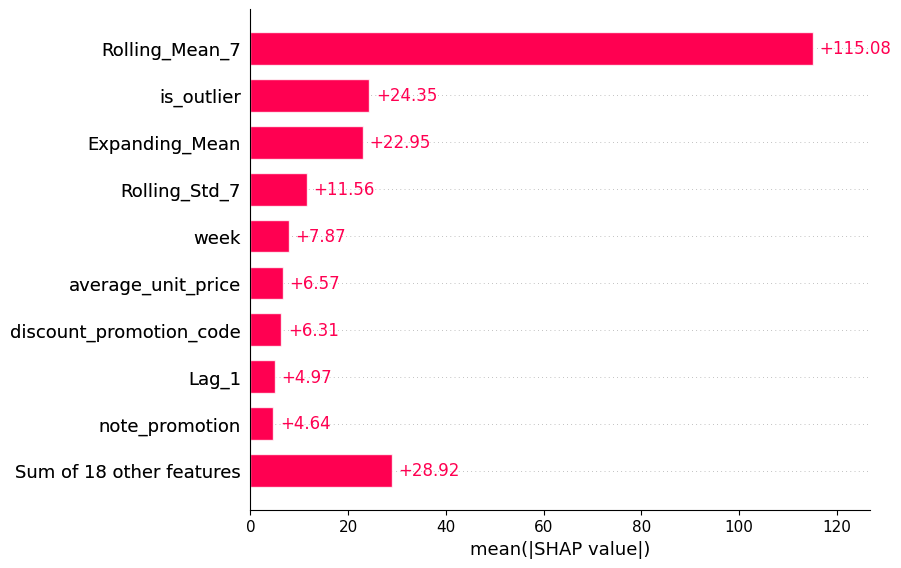

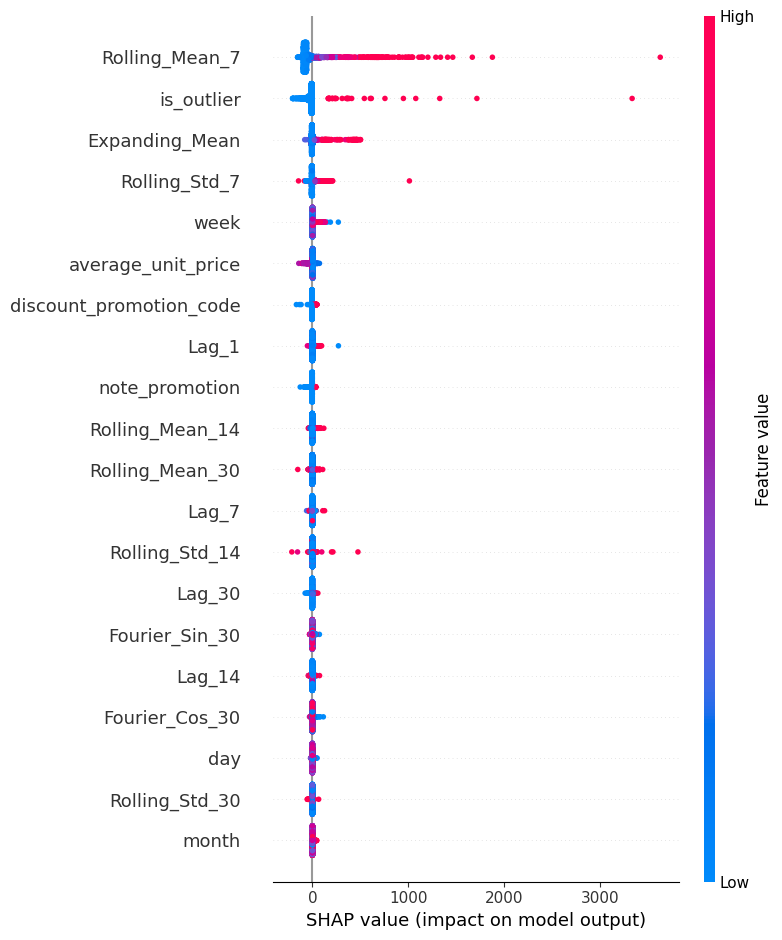

In [74]:
#SHAP values cho RF2 -> Tương tư như XGB2, khi Rolling_mean_7 vẫn ảnh hưởng lớn nhất
import shap

X_train_shap = train[features].copy().astype("float64")
X_test_shap = test[features].copy().astype("float64")

X_test_shap = X_test_shap[X_train_shap.columns]

explainer = shap.TreeExplainer(model4)

shap_values = explainer.shap_values(X_test_shap, check_additivity=False)

explanation = shap.Explanation(
    values=shap_values,
    data=X_test_shap,
    feature_names=X_test_shap.columns
)

shap.plots.bar(explanation)
shap.summary_plot(shap_values, X_test_shap, feature_names=X_test_shap.columns)

In [75]:
#Kiểm tra stability RF2 -> Tương đương XGB2
print("Metric Stability Across Folds:")
print(f"MAE Std: {np.std(mae_scores4):.4f}")
print(f"MSE Std: {np.std(mse_scores4):.4f}")
print(f"R² Std:  {np.std(r2_scores4):.4f}")

def stability_index(metric_list):
    return np.std(metric_list) / (np.mean(metric_list) + 1e-6)

print(f"MAE Stability Index: {stability_index(mae_scores4):.4f}")
print(f"R² Stability Index:  {stability_index(r2_scores4):.4f}")

Metric Stability Across Folds:
MAE Std: 27.7764
MSE Std: 63453.8593
R² Std:  0.0853
MAE Stability Index: 0.2506
R² Stability Index:  0.1887


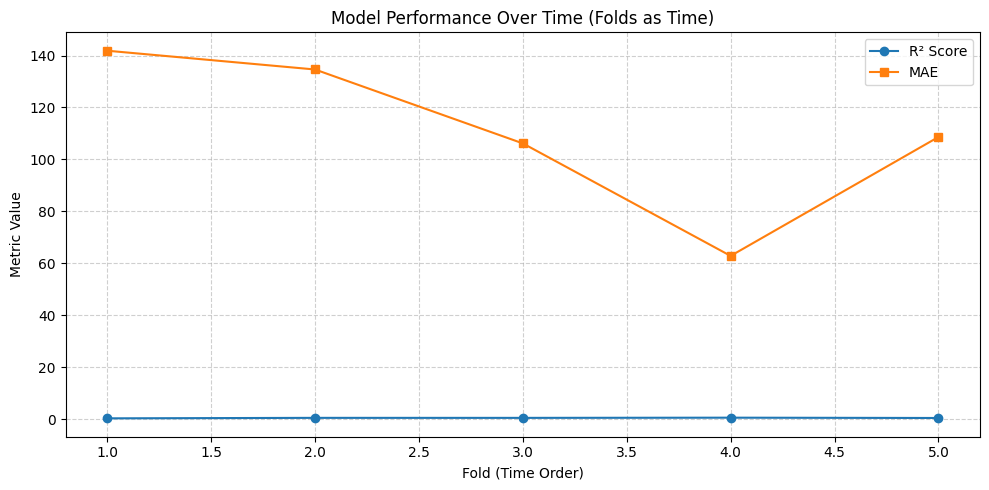

📉 R² decay per fold: 0.0343
📈 MAE increase per fold: -13.8237


In [76]:
#Trend tương tự XGB2, cải thiện dần theo thời gian
folds = list(range(1, len(r2_scores4) + 1))

plt.figure(figsize=(10, 5))
plt.plot(folds, r2_scores4, marker='o', label='R² Score')
plt.plot(folds, mae_scores4, marker='s', label='MAE')
plt.title('Model Performance Over Time (Folds as Time)')
plt.xlabel('Fold (Time Order)')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

X_fold = np.array(folds).reshape(-1, 1)
r2_trend = LinearRegression().fit(X_fold, r2_scores4)
mae_trend = LinearRegression().fit(X_fold, mae_scores4)

r2_slope = r2_trend.coef_[0]
mae_slope = mae_trend.coef_[0]

print(f"📉 R² decay per fold: {r2_slope:.4f}")
print(f"📈 MAE increase per fold: {mae_slope:.4f}")

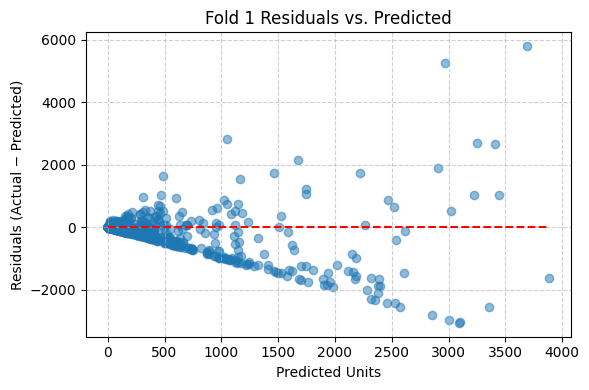

Fold 1 MAE: 138.983  R²: 0.310  MSE: 172513.108


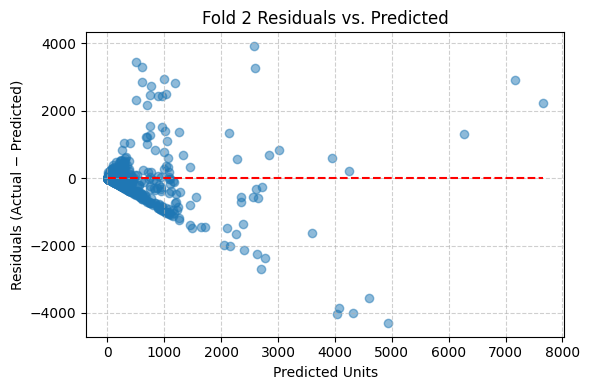

Fold 2 MAE: 134.135  R²: 0.493  MSE: 173683.338


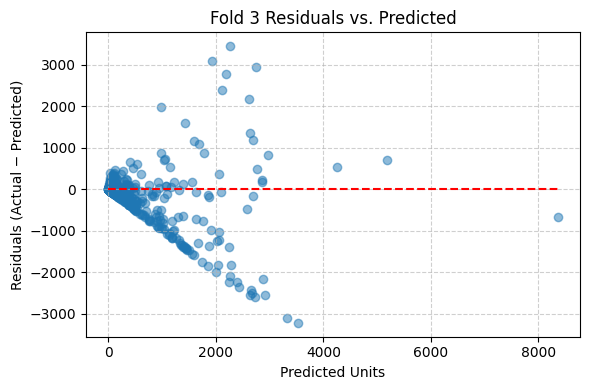

Fold 3 MAE: 106.614  R²: 0.474  MSE: 120565.425


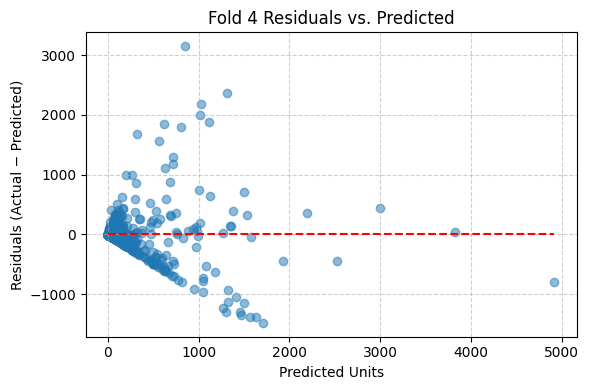

Fold 4 MAE: 63.788  R²: 0.548  MSE: 45365.812


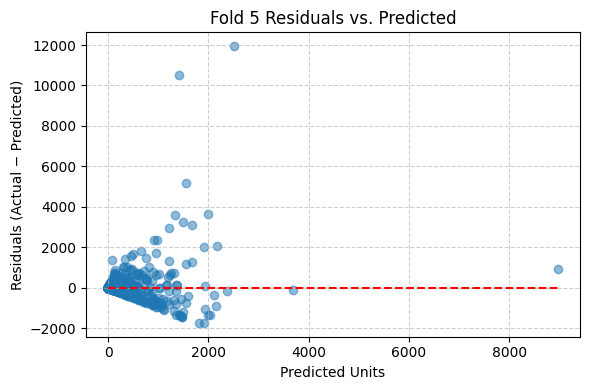

Fold 5 MAE: 107.948  R²: 0.441  MSE: 230342.118


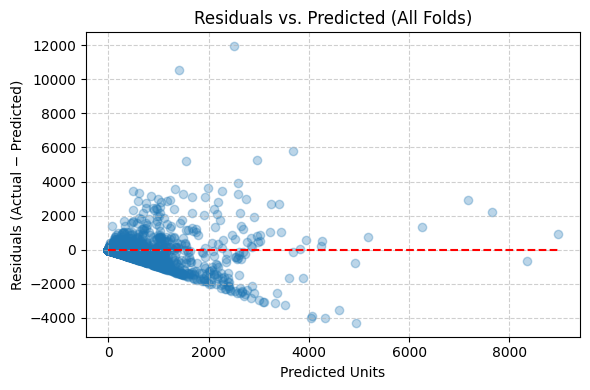

In [77]:
#RF2 retrain + Residual analysis + Actual vs Predicted plot -> Cần xem kỹ hơn model có vấn đề ở đâu
#-> Residual plot cho thấy model dự báo khá tốt cho đơn hàng nhỏ-trung bình, nhưng hay sai nhiều cho đơn hàng lớn hay là các outlier
import matplotlib.pyplot as plt

mae_scores4 = []
r2_scores4 = []
mse_scores4 = []
fold4 = 1

all_actuals = []
all_preds   = []

for train_index, test_index in tscv.split(agg_df):
    train, test = agg_df.iloc[train_index], agg_df.iloc[test_index]
    
    model4 = RandomForestRegressor(max_depth=10, min_samples_split=2, n_estimators=200)
    model4.fit(train[features], train[target])
    
    predictions = model4.predict(test[features])
    
    residuals = test[target] - predictions
    
    plt.figure(figsize=(6,4))
    plt.scatter(predictions, residuals, alpha=0.5)
    plt.hlines(0, predictions.min(), predictions.max(), colors='red', linestyles='--')
    plt.xlabel("Predicted Units")
    plt.ylabel("Residuals (Actual − Predicted)")
    plt.title(f"Fold {fold4} Residuals vs. Predicted")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    all_actuals.append(test[target])
    all_preds.append(predictions)
    
    mae4 = mean_absolute_error(test[target], predictions)
    mse4 = mean_squared_error(test[target], predictions)
    r24 = r2_score(test[target], predictions)
    mae_scores4.append(mae4)
    r2_scores4.append(r24)
    mse_scores4.append(mse4)
    
    print(f"Fold {fold4} MAE: {mae4:.3f}  R²: {r24:.3f}  MSE: {mse4:.3f}")
    fold4 += 1

all_actuals = np.concatenate(all_actuals)
all_preds   = np.concatenate(all_preds)
residuals   = all_actuals - all_preds

plt.figure(figsize=(6,4))
plt.scatter(all_preds, residuals, alpha=0.3)
plt.hlines(0, all_preds.min(), all_preds.max(), colors='red', linestyles='--')
plt.xlabel("Predicted Units")
plt.ylabel("Residuals (Actual − Predicted)")
plt.title("Residuals vs. Predicted (All Folds)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [78]:
#Bảng tổng so sánh 4 experiments (XGB1, RF1, XGB2, RF2) -> XGB2 cho MAE tốt nhất (~107). RF2 R² tương đương (~45%). Cả 2 model sau fine-tune đều tốt hơn baseline rõ rệt
fold_results = []
for fold_idx in range(len(mae_scores1)):
    fold_results.append({
        'Fold': fold_idx + 1,
        'XGB1_MAE': mae_scores1[fold_idx],
        'XGB1_R2': r2_scores1[fold_idx],
        'XGB1_MSE': mse_scores1[fold_idx],
        'RF1_MAE': mae_scores2[fold_idx],
        'RF1_R2': r2_scores2[fold_idx],
        'RF1_MSE': mse_scores2[fold_idx],
        'XGB2_MAE': mae_scores3[fold_idx],
        'XGB2_R2': r2_scores3[fold_idx],
        'XGB2_MSE': mse_scores3[fold_idx],
        'RF2_MAE': mae_scores4[fold_idx],
        'RF2_R2': r2_scores4[fold_idx],
        'RF2_MSE': mse_scores4[fold_idx],
    })

comparison_df = pd.DataFrame(fold_results)

avg_row = {
    'Fold': 'Average',
    'XGB1_MAE': np.mean(mae_scores1),
    'XGB1_R2': np.mean(r2_scores1),
    'XGB1_MSE': np.mean(mse_scores1),
    'RF1_MAE': np.mean(mae_scores2),
    'RF1_R2': np.mean(r2_scores2),
    'RF1_MSE': np.mean(mse_scores2),
    'XGB2_MAE': np.mean(mae_scores3),
    'XGB2_R2': np.mean(r2_scores3),
    'XGB2_MSE': np.mean(mse_scores3),
    'RF2_MAE': np.mean(mae_scores4),
    'RF2_R2': np.mean(r2_scores4),
    'RF2_MSE': np.mean(mse_scores4),
}

avg_df = pd.DataFrame([avg_row])
comparison_df = pd.concat([comparison_df, avg_df], ignore_index=True)

print(comparison_df)

      Fold    XGB1_MAE   XGB1_R2       XGB1_MSE     RF1_MAE    RF1_R2  \
0        1  128.190216  0.324198  169062.125000  144.908655  0.289438   
1        2  124.387749  0.509070  168190.359375  140.360216  0.486354   
2        3  120.287163  0.257422  170260.828125  114.889277  0.398687   
3        4   66.087036  0.447704   55463.511719   64.340336  0.551826   
4        5  106.193550  0.419655  239058.500000  110.713914  0.448409   
5  Average  109.029143  0.391610  160407.064844  115.042480  0.434943   

         RF1_MSE    XGB2_MAE   XGB2_R2       XGB2_MSE     RF2_MAE    RF2_R2  \
0  177757.912362  119.303650  0.418819  145391.359375  138.982530  0.310403   
1  175972.830029  123.714310  0.527818  161767.281250  134.135233  0.493037   
2  137871.100670  119.068382  0.324605  154856.828125  106.614280  0.474164   
3   45007.193297   67.523460  0.530114   47187.578125   63.787546  0.548255   
4  227214.224525  108.699028  0.381068  254953.671875  107.948365  0.440816   
5  152764.6521

In [79]:
#Thử RF với log transform target vì trước đó target bị skew phải nặng, thử log transform để model dự báo tốt hơn
#Train RF với y_train = log(unit+1), inverse transform khi predict. So sánh train vs test metrics để check overfit

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
train_r2, test_r2 = [], []
train_mae, test_mae = [], []
train_mse, test_mse = [], []

for train_idx, test_idx in tscv.split(agg_df):
    train, test = agg_df.iloc[train_idx], agg_df.iloc[test_idx]
    
    y_train_log = np.log(train[target] + 1)
    
    model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    model.fit(train[features], y_train_log)
    
    y_train_pred_log = model.predict(train[features])
    y_test_pred_log  = model.predict(test[features])
    
    y_train_pred = np.exp(y_train_pred_log) - 1
    y_test_pred  = np.exp(y_test_pred_log)  - 1
    
    train_r2.append(r2_score(train[target], y_train_pred))
    test_r2.append (r2_score(test[target],  y_test_pred))
    train_mae.append(mean_absolute_error(train[target], y_train_pred))
    test_mae.append (mean_absolute_error(test[target],  y_test_pred))
    train_mse.append(mean_squared_error(train[target], y_train_pred))
    test_mse.append (mean_squared_error(test[target],  y_test_pred))

print("Log‐Transform Results:")
print(f"Avg Train R²: {np.mean(train_r2):.3f}   Avg Test R²: {np.mean(test_r2):.3f}")
print(f"Avg Train MAE: {np.mean(train_mae):.3f}  Avg Test MAE:  {np.mean(test_mae):.3f}")
print(f"Avg Train MSE: {np.mean(train_mse):.3f}  Avg Test MSE: {np.mean(test_mse):.3f}")


Log‐Transform Results:
Avg Train R²: 0.592   Avg Test R²: 0.316
Avg Train MAE: 61.307  Avg Test MAE:  88.994
Avg Train MSE: 106789.068  Avg Test MSE: 192374.283


Overall, Log-transfrom cho ra MAE thấp nhất (88.99) trong số các experiments nhưng khả năng giải thích các variance kém hơn các moel kia khi R² thấp nhất
Tuy nhiên bài toán quan tâm nhiều đến độ chính xác trung bình ngày thường để đảm bảo được việc dự báo nhằm giảm thiểu rủi ro trong vấn đề cung ứng đặt hàng sản xuất, do đó sẽ lựa chọn phương án có MAE thấp nhất -> RF + Log-transform